In [ ]:

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.large_repr", "truncate")

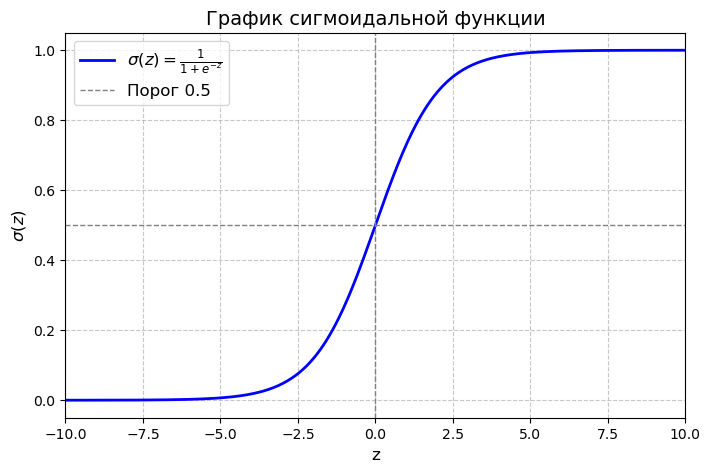

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Определение сигмоидной функции
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Создание массива значений от -10 до 10
z = np.linspace(-10, 10, 400)
s = sigmoid(z)

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(z, s, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$', color='blue', linewidth=2)

# Настройка внешнего вида
plt.title('График сигмоидальной функции', fontsize=14)
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$\sigma(z)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Порог 0.5')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.legend(fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xlim(-10, 10)

# Отображение графика
plt.show()

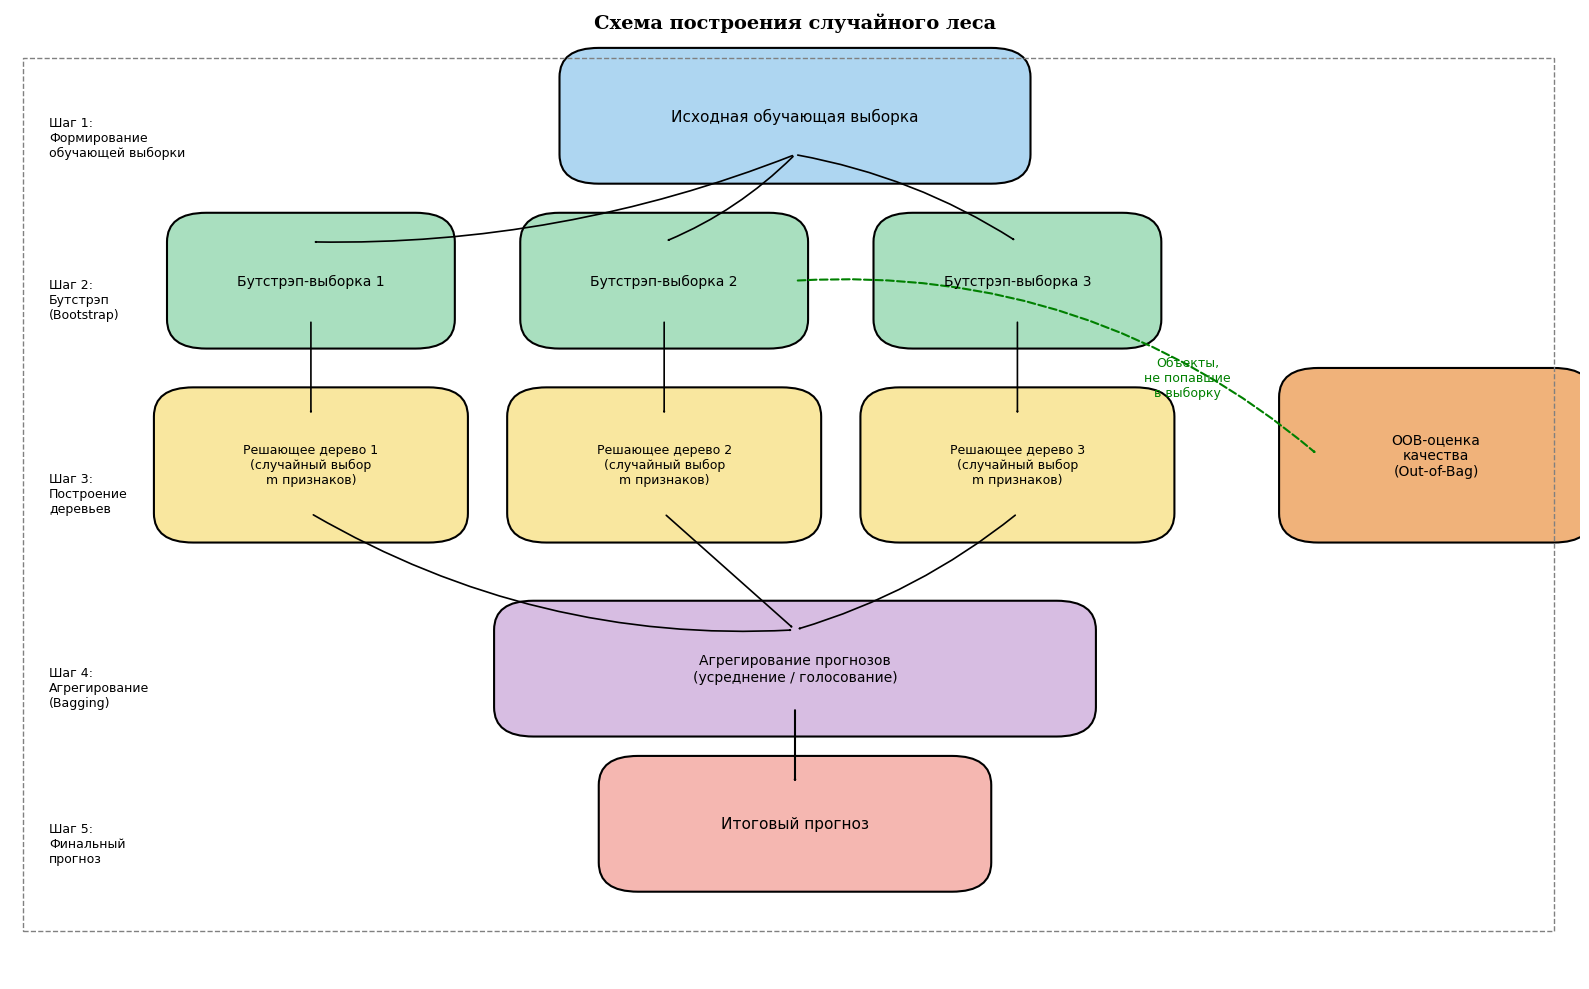

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Увеличиваем ширину фигуры для дополнительного пространства справа
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

def add_box(ax, xy, width, height, text, boxstyle="round,pad=0.3",
            facecolor='lightblue', edgecolor='black', linewidth=1.5, fontsize=10):
    box = FancyBboxPatch(xy, width, height,
                         boxstyle=boxstyle,
                         facecolor=facecolor,
                         edgecolor=edgecolor,
                         linewidth=linewidth)
    ax.add_patch(box)
    ax.text(xy[0] + width/2, xy[1] + height/2, text,
            ha='center', va='center', fontsize=fontsize, wrap=True)

def add_arrow(ax, start, end, style='->', color='black', linewidth=1.2,
              linestyle='-', connectionstyle='arc3,rad=0.0'):
    arrow = FancyArrowPatch(start, end,
                            arrowstyle=style,
                            color=color,
                            linewidth=linewidth,
                            linestyle=linestyle,
                            connectionstyle=connectionstyle)
    ax.add_patch(arrow)

# --- Основные блоки ---
# Исходная обучающая выборка (центрируем по новой ширине ~6.0)
add_box(ax, (4.5, 8.5), 3.0, 0.8, "Исходная обучающая выборка",
        facecolor='#AED6F1', fontsize=11)

# Бутстрэп-выборки (три блока, сдвинуты левее, чтобы освободить место справа)
bootstrap_y = 6.8
bootstrap_width = 1.6
bootstrap_height = 0.8
positions = [1.5, 4.2, 6.9]  # сдвинули левее
for i, pos in enumerate(positions, 1):
    add_box(ax, (pos, bootstrap_y), bootstrap_width, bootstrap_height,
            f"Бутстрэп-выборка {i}", facecolor='#A9DFBF', fontsize=10)

# Решающие деревья (под бутстрэп-выборками)
tree_y = 4.8
tree_width = 1.8
tree_height = 1.0
for i, pos in enumerate(positions, 1):
    add_box(ax, (pos-0.1, tree_y), tree_width, tree_height,
            f"Решающее дерево {i}\n(случайный выбор\nm признаков)",
            facecolor='#F9E79F', fontsize=9)

# Агрегирование прогнозов (по центру относительно деревьев)
add_box(ax, (4.0, 2.8), 4.0, 0.8, "Агрегирование прогнозов\n(усреднение / голосование)",
        facecolor='#D7BDE2', fontsize=10)

# Итоговый прогноз (под агрегированием)
add_box(ax, (4.8, 1.2), 2.4, 0.8, "Итоговый прогноз",
        facecolor='#F5B7B1', fontsize=11)

# OOB-оценка качества (сдвинут далеко вправо, чтобы не накладываться)
add_box(ax, (10.0, 4.8), 1.8, 1.2, "OOB-оценка\nкачества\n(Out-of-Bag)",
        facecolor='#F0B27A', fontsize=10)

# --- Стрелки ---
# От исходной выборки к бутстрэп-выборкам
start_center = (6.0, 8.5)
for pos in positions:
    end_top = (pos + bootstrap_width/2, bootstrap_y + bootstrap_height)
    add_arrow(ax, start_center, end_top, style='->', linewidth=1.2,
              connectionstyle='arc3,rad=-0.1')

# От бутстрэп-выборок к решающим деревьям
for i, pos in enumerate(positions):
    start_bottom = (pos + bootstrap_width/2, bootstrap_y)
    end_top_tree = (pos - 0.1 + tree_width/2, tree_y + tree_height)
    add_arrow(ax, start_bottom, end_top_tree, style='->', linewidth=1.2)

# От решающих деревьев к агрегированию
agg_top_center = (6.0, 3.6)
for i, pos in enumerate(positions):
    start_bottom_tree = (pos - 0.1 + tree_width/2, tree_y)
    add_arrow(ax, start_bottom_tree, agg_top_center, style='->', linewidth=1.2,
              connectionstyle=f'arc3,rad={0.15 if i==0 else (-0.1 if i==2 else 0.0)}')

# От агрегирования к итоговому прогнозу
add_arrow(ax, (6.0, 2.8), (6.0, 2.0), style='->', linewidth=1.5)

# Пунктирная стрелка от бутстрэп-выборки 2 к OOB (пересчитаны координаты)
oob_start = (positions[1] + bootstrap_width + 0.2, bootstrap_y + bootstrap_height/2)
oob_end = (10.0, 5.4)
add_arrow(ax, oob_start, oob_end, style='->', color='green', linewidth=1.5,
          linestyle='dashed', connectionstyle='arc3,rad=-0.2')

# Подпись к пунктирной стрелке
ax.text(9.0, 6.2, "Объекты,\nне попавшие\nв выборку", fontsize=9, color='green',
        ha='center', va='center')

# --- Подписи к этапам (слева) ---
ax.text(0.3, 8.9, "Шаг 1:\nФормирование\nобучающей выборки", fontsize=9, va='top')
ax.text(0.3, 7.0, "Шаг 2:\nБутстрэп\n(Bootstrap)", fontsize=9, va='center')
ax.text(0.3, 5.0, "Шаг 3:\nПостроение\nдеревьев", fontsize=9, va='center')
ax.text(0.3, 3.0, "Шаг 4:\nАгрегирование\n(Bagging)", fontsize=9, va='center')
ax.text(0.3, 1.4, "Шаг 5:\nФинальный\nпрогноз", fontsize=9, va='center')

# Рамка вокруг всей схемы (увеличена ширина)
rect = mpatches.Rectangle((0.1, 0.5), 11.7, 9.0, fill=False, edgecolor='gray',
                           linestyle='--', linewidth=1)
ax.add_patch(rect)

# Заголовок
ax.text(6.0, 9.8, "Схема построения случайного леса", ha='center', fontsize=14,
        fontweight='bold', family='serif')

plt.tight_layout()
plt.savefig('random_forest_scheme_fixed.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

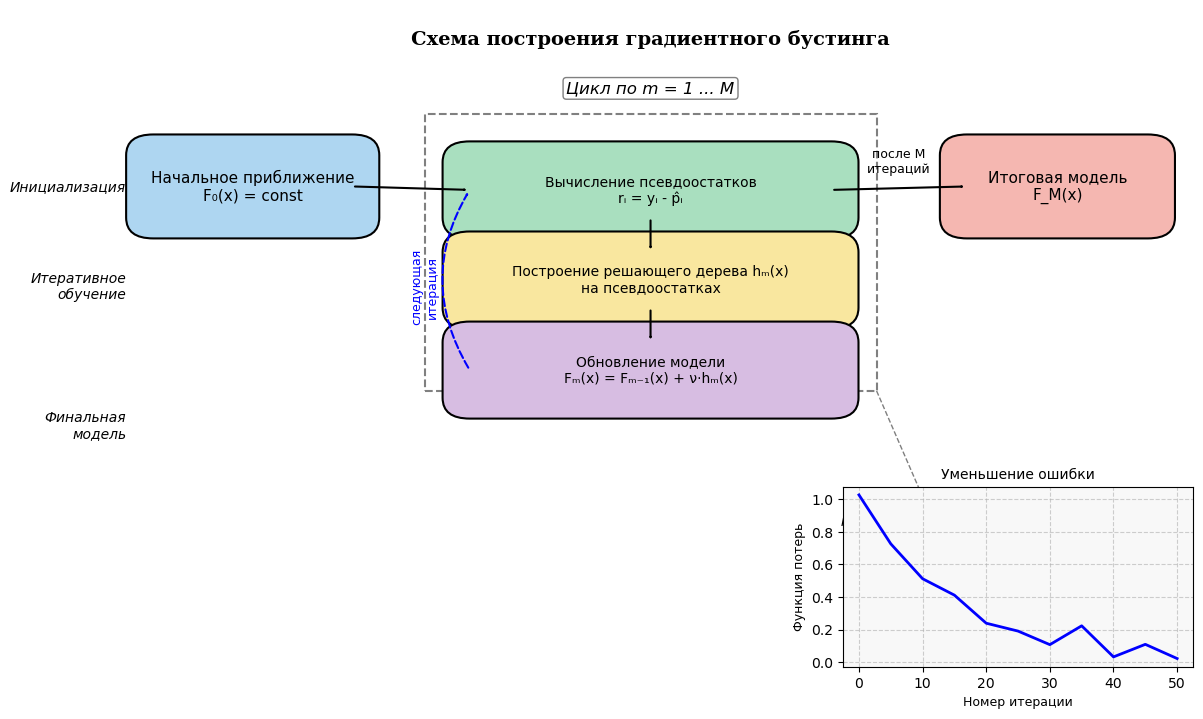

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# Настройка фигуры
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

# Функция для добавления прямоугольника с текстом
def add_box(ax, xy, width, height, text, boxstyle="round,pad=0.3",
            facecolor='lightblue', edgecolor='black', linewidth=1.5, fontsize=10):
    box = FancyBboxPatch(xy, width, height,
                         boxstyle=boxstyle,
                         facecolor=facecolor,
                         edgecolor=edgecolor,
                         linewidth=linewidth)
    ax.add_patch(box)
    ax.text(xy[0] + width/2, xy[1] + height/2, text,
            ha='center', va='center', fontsize=fontsize, wrap=True)

# Функция для добавления стрелки
def add_arrow(ax, start, end, style='->', color='black', linewidth=1.2,
              linestyle='-', connectionstyle='arc3,rad=0.0'):
    arrow = FancyArrowPatch(start, end,
                            arrowstyle=style,
                            color=color,
                            linewidth=linewidth,
                            linestyle=linestyle,
                            connectionstyle=connectionstyle)
    ax.add_patch(arrow)

# --- Основные блоки схемы ---

# 1. Начальное приближение (слева)
add_box(ax, (0.5, 7.0), 2.2, 0.9, "Начальное приближение\nF₀(x) = const",
        facecolor='#AED6F1', fontsize=11)

# 2. Блок цикла (рамка с подписью "Цикл по m = 1...M")
cycle_rect = mpatches.Rectangle((3.5, 4.5), 5.0, 4.0, fill=False, edgecolor='gray',
                                 linestyle='--', linewidth=1.5)
ax.add_patch(cycle_rect)
ax.text(6.0, 8.8, "Цикл по m = 1 ... M", ha='center', fontsize=12, style='italic',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='gray'))

# Шаги внутри цикла (расположены вертикально)
# Шаг 1: Вычисление псевдоостатков
add_box(ax, (4.0, 7.0), 4.0, 0.8, "Вычисление псевдоостатков\nrᵢ = yᵢ - p̂ᵢ",
        facecolor='#A9DFBF', fontsize=10)

# Шаг 2: Построение дерева
add_box(ax, (4.0, 5.7), 4.0, 0.8, "Построение решающего дерева hₘ(x)\nна псевдоостатках",
        facecolor='#F9E79F', fontsize=10)

# Шаг 3: Обновление модели
add_box(ax, (4.0, 4.4), 4.0, 0.8, "Обновление модели\nFₘ(x) = Fₘ₋₁(x) + ν·hₘ(x)",
        facecolor='#D7BDE2', fontsize=10)

# Стрелки между шагами цикла
add_arrow(ax, (6.0, 7.0), (6.0, 6.5), style='->', linewidth=1.5)  # 1 -> 2
add_arrow(ax, (6.0, 5.7), (6.0, 5.2), style='->', linewidth=1.5)  # 2 -> 3

# 3. Итоговая модель (после цикла, справа)
add_box(ax, (9.5, 7.0), 2.0, 0.9, "Итоговая модель\nF_M(x)",
        facecolor='#F5B7B1', fontsize=11)

# Стрелка от начального приближения к первому шагу цикла
add_arrow(ax, (2.7, 7.45), (4.0, 7.4), style='->', linewidth=1.5)

# Стрелка от последнего шага цикла обратно наверх (итерация) - дуговая
add_arrow(ax, (4.0, 4.8), (4.0, 7.4), style='->', color='blue', linewidth=1.5,
          linestyle='dashed', connectionstyle='arc3,rad=-0.3')
ax.text(3.5, 6.0, "следующая\nитерация", fontsize=9, color='blue', ha='center', va='center',
        rotation=90)

# Стрелка от цикла к итоговой модели (после завершения всех итераций)
add_arrow(ax, (8.0, 7.4), (9.5, 7.45), style='->', linewidth=1.5)
ax.text(8.75, 7.8, "после M\nитераций", fontsize=9, ha='center', va='center')

# --- График уменьшения функции потерь (справа внизу) ---
loss_ax = fig.add_axes([0.65, 0.15, 0.25, 0.2])  # [left, bottom, width, height]
iterations = np.arange(0, 51, 5)
loss = np.exp(-iterations / 15) + 0.1 * np.random.randn(len(iterations)) * 0.5
loss_ax.plot(iterations, loss, 'b-', linewidth=2)
loss_ax.set_xlabel("Номер итерации", fontsize=9)
loss_ax.set_ylabel("Функция потерь", fontsize=9)
loss_ax.set_title("Уменьшение ошибки", fontsize=10)
loss_ax.grid(True, linestyle='--', alpha=0.6)
loss_ax.set_facecolor('#f8f8f8')

# Подпись к графику
ax.text(9.0, 2.5, "График функции потерь\n(убывает с ростом M)",
        fontsize=9, ha='center', va='center', style='italic')

# Соединительная линия от цикла к графику (необязательно)
ax.plot([8.5, 9.0], [4.5, 3.0], 'k--', linewidth=1, alpha=0.5)

# --- Подписи слева ---
ax.text(0.2, 7.45, "Инициализация", fontsize=10, ha='right', va='center', style='italic')
ax.text(0.2, 6.0, "Итеративное\nобучение", fontsize=10, ha='right', va='center', style='italic')
ax.text(0.2, 4.0, "Финальная\nмодель", fontsize=10, ha='right', va='center', style='italic')

# Заголовок
ax.text(6.0, 9.5, "Схема построения градиентного бустинга", ha='center', fontsize=14,
        fontweight='bold', family='serif')

plt.savefig('gradient_boosting_scheme.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Практическая часть

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

100%|██████████| 1.26G/1.26G [00:08<00:00, 156MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


Данные загружены. Размер: (2260701, 151)


In [ ]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [ ]:
# Список признаков, указанных в описании исследования
selected_columns = [
    'loan_amnt',        # Сумма кредита
    'term',             # Срок кредита в месяцах
    'int_rate',         # Процентная ставка
    'installment',      # Ежемесячный платеж
    'grade',            # Класс кредита
    'sub_grade',        # Подкласс кредита
    'emp_title',        # Название должности
    'emp_length',       # Продолжительность трудовой деятельности
    'home_ownership',   # Статус владения жильем
    'annual_inc',       # Годовой доход
    'verification_status', # Статус проверки дохода
    'issue_d',          # Месяц выдачи займа
    'loan_status',      # Текущий статус займа (целевая переменная)
    'purpose',          # Цель займа
    'title',            # Обозначение кредита
    'dti',              # Долговая нагрузка (Debt-to-Income)
    'addr_state',       # Штат проживания
    'open_acc',         # Количество открытых кредитных линий
    'pub_rec',          # Количество негативных публичных записей
    'revol_bal',        # Общий остаток по возобновляемым кредитам
    'revol_util',       # Коэффициент использования возобновляемой линии
    'total_acc',        # Общее количество кредитных линий
    'initial_list_status', # Статус первоначального листинга
    'application_type', # Тип заявки (индивидуальная/совместная)
    'mort_acc'       # Количество ипотечных счетов
]

# Оставляем только те колонки, которые присутствуют в датасете
existing_columns = [col for col in selected_columns if col in df.columns]
df_filtered = df[existing_columns].copy()

# Проверка, какие колонки были пропущены (отсутствовали в исходном датасете)
missing_columns = set(selected_columns) - set(existing_columns)
if missing_columns:
    print(f"Внимание: следующие колонки не найдены в датасете: {missing_columns}")

print(f"Размер исходного датасета: {df.shape}")
print(f"Размер отфильтрованного датасета: {df_filtered.shape}")

Размер исходного датасета: (2260701, 151)
Размер отфильтрованного датасета: (2260701, 25)


In [ ]:
df = df_filtered.copy()

In [ ]:
# ---------------------------------------------------------------------
# 2. Фильтрация целевой переменной и удаление неинформативных статусов
# ---------------------------------------------------------------------
# Оставляем только завершённые займы (Fully Paid и Charged Off)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

In [ ]:
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


In [ ]:
# ---------------------------------------------------------------------
# 1. Целевая переменная
# ---------------------------------------------------------------------
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

# ---------------------------------------------------------------------
# 2. Отбор признаков
# ---------------------------------------------------------------------
features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'dti', 'addr_state',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'initial_list_status', 'application_type', 'mort_acc'
]
df = df.dropna(subset=features + ['default']).copy()

X = df[features].copy()
y = df['default'].copy()


# ---------------------------------------------------------------------
# 3. Единая предобработка для всех моделей (Label Encoding)
# ---------------------------------------------------------------------
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Применяем Label Encoding ко всем категориальным признакам
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Теперь все признаки числовые
feature_names = X.columns.tolist()

# Масштабируем числовые признаки (рекомендуется для SGDClassifier)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Создаём DataFrame с именами (для удобства SHAP, если потребуется)
X_processed = pd.DataFrame(X_scaled, columns=feature_names)

# ---------------------------------------------------------------------
# 4. Разделение на train/test (один раз для всех)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:   {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")

Обучающая выборка: (971212, 22)
Тестовая выборка:   (242803, 22)
Количество признаков: 22


In [ ]:


# ---------------------------------------------------------------------
# 5. Обучение моделей
# ---------------------------------------------------------------------
results = {}

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name):
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    precision = precision_score(y_true, y_pred_class)
    recall = recall_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)
    results[model_name] = {
        'ROC-AUC': auc, 'Gini': gini,
        'Precision': precision, 'Recall': recall, 'F1': f1
    }
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {auc:.4f}  |  Gini: {gini:.4f}")
    print(f"  Precision: {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}")

# 5.1 Логистическая регрессия
print("Обучение логистической регрессии (SGD)...")
lr_model = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001,
                         max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_class_lr = (y_pred_proba_lr >= 0.5).astype(int)
evaluate_model(y_test, y_pred_proba_lr, y_pred_class_lr, "Logistic Regression")

# 5.2 Случайный лес
print("\nОбучение случайного леса...")
rf_model = RandomForestClassifier(
    n_estimators=50,          # Уменьшено для экономии памяти и времени
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)
evaluate_model(y_test, y_pred_proba_rf, y_pred_class_rf, "Random Forest")


# ---------------------------------------------------------------------
# 6. Сводная таблица
# ---------------------------------------------------------------------
results_df = pd.DataFrame(results).T
print("\n=== Итоговые метрики ===")
print(results_df.round(4))



Обучение логистической регрессии (SGD)...

Logistic Regression:
  ROC-AUC: 0.7084  |  Gini: 0.4168
  Precision: 0.5156  |  Recall: 0.0895  |  F1: 0.1525

Обучение случайного леса...

Random Forest:
  ROC-AUC: 0.7151  |  Gini: 0.4301
  Precision: 0.5754  |  Recall: 0.0396  |  F1: 0.0741

=== Итоговые метрики ===
                     ROC-AUC  Gini  Precision  Recall   F1
Logistic Regression     0.71  0.42       0.52    0.09 0.15
Random Forest           0.72  0.43       0.58    0.04 0.07


In [ ]:
# 5.3 Градиентный бустинг (если установлен XGBoost)
try:
    from xgboost import XGBClassifier
    print("\nОбучение градиентного бустинга (XGBoost)...")
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_class_xgb = (y_pred_proba_xgb >= 0.5).astype(int)
    evaluate_model(y_test, y_pred_proba_xgb, y_pred_class_xgb, "Gradient Boosting")
except ImportError:
    print("XGBoost не установлен, пропускаем...")

# ---------------------------------------------------------------------
# 6. Сводная таблица
# ---------------------------------------------------------------------
results_df = pd.DataFrame(results).T
print("\n=== Итоговые метрики ===")
print(results_df.round(4))


Обучение градиентного бустинга (XGBoost)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:41:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Gradient Boosting:
  ROC-AUC: 0.7203  |  Gini: 0.4406
  Precision: 0.5776  |  Recall: 0.0590  |  F1: 0.1071

=== Итоговые метрики ===
                     ROC-AUC  Gini  Precision  Recall   F1
Logistic Regression     0.71  0.42       0.52    0.09 0.15
Random Forest           0.72  0.43       0.58    0.04 0.07
Gradient Boosting       0.72  0.44       0.58    0.06 0.11


In [ ]:
# Проверяем, обучена ли модель XGBoost
if 'xgb_model' in locals():
    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_shap)

    # XGBoost возвращает один массив для положительного класса
    xgb_importance = np.abs(shap_values_xgb).mean(axis=0)
    xgb_importance_df = pd.DataFrame({
        'feature': X_shap.columns,
        'mean_abs_shap': xgb_importance
    }).sort_values('mean_abs_shap', ascending=False)

    print("Топ-3 признака по SHAP для градиентного бустинга:")
    for i, row in xgb_importance_df.head(3).iterrows():
        print(f"  {row['feature']}: {row['mean_abs_shap']:.4f}")
else:
    print("Модель XGBoost не найдена. Запустите обучение градиентного бустинга.")

Модель XGBoost не найдена. Запустите обучение градиентного бустинга.


## новые признаки

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'addr_state', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'application_type', 'mort_acc',
       'default'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# Предполагается, что df уже загружен (полный accepted_2007_to_2018Q4.csv.gz)
# Или можно выполнить загрузку заново:
# import kagglehub, os
# path = kagglehub.dataset_download("wordsforthewise/lending-club")
# df = pd.read_csv(os.path.join(path, "accepted_2007_to_2018Q4.csv.gz"), low_memory=False)

# Копия для чистоты
data = df.copy()

# ---------------------------------------------------------------------
# 1. Целевая переменная – только завершённые кредиты
# ---------------------------------------------------------------------
data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ---------------------------------------------------------------------
# 2. Создание новых признаков
# ---------------------------------------------------------------------
# 2.1 Логарифм годового дохода
data['annual_inc_log'] = np.log1p(data['annual_inc'])

# 2.2 Средний FICO
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2

# 2.3 Длина кредитной истории (в месяцах)
# Преобразуем даты
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_history_length_months'] = (
    (data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
    (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month)
)
# Отрицательные значения (если earliest позже issue) маловероятны, но заменим на NaN
data.loc[data['credit_history_length_months'] < 0, 'credit_history_length_months'] = np.nan

# 2.4 Преобразуем term в числовой вид (36 или 60)
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# ---------------------------------------------------------------------
# 3. Отбор финального списка признаков
# ---------------------------------------------------------------------
feature_cols = [
    'sub_grade',
    'term_num',
    'dti',
    'home_ownership',
    'annual_inc_log',
    'fico_avg',
    'credit_history_length_months',
    'revol_util',
    'revol_bal',
    'delinq_2yrs',
    'pub_rec',
    'inq_last_6mths',
    'open_acc',
    'total_acc',
    'mort_acc',
    'collections_12_mths_ex_med',
    'verification_status',
    'purpose',
    'open_il_12m',
    'acc_now_delinq'
]

# Убедимся, что все колонки существуют
missing = [c for c in feature_cols if c not in data.columns]
if missing:
    print("Отсутствуют колонки:", missing)
    # Если каких-то нет, можно обработать дополнительно, но они должны быть
    # Например, open_il_12m может называться open_il_12m или как-то иначе, проверим
    # В Lending Club колонка называется open_il_12m – есть.

# Удаляем строки с пропусками в отобранных признаках и целевой переменной
data = data.dropna(subset=feature_cols + ['default'])

print(f"Размер после удаления пропусков: {data.shape}")

X = data[feature_cols].copy()
y = data['default'].copy()

# ---------------------------------------------------------------------
# 4. Предобработка: категориальные признаки - Label Encoding, затем масштабирование
# ---------------------------------------------------------------------
# Определяем категориальные (те, что 'object') после всех преобразований.
# term_num, dti и другие – числовые, home_ownership, verification_status, purpose, sub_grade – объекты
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Категориальные признаки: {categorical_cols}")
print(f"Числовые признаки: {numeric_cols}")

# Label Encoding для категорий
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Теперь все признаки числовые
feature_names = X.columns.tolist()

# Масштабирование (обязательно для SGDClassifier)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_processed = pd.DataFrame(X_scaled, columns=feature_names)

# ---------------------------------------------------------------------
# 5. Разделение на train/test
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:   {X_test.shape}")

# ---------------------------------------------------------------------
# 6. Обучение моделей
# ---------------------------------------------------------------------
results = {}

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name):
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    precision = precision_score(y_true, y_pred_class)
    recall = recall_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)
    results[model_name] = {
        'ROC-AUC': auc, 'Gini': gini,
        'Precision': precision, 'Recall': recall, 'F1': f1
    }
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {auc:.4f}  |  Gini: {gini:.4f}")
    print(f"  Precision: {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}")

# 6.1 Логистическая регрессия
print("Обучение логистической регрессии (SGD)...")
lr_model = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001,
                         max_iter=1000, tol=1e-3, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_class_lr = (y_pred_proba_lr >= 0.5).astype(int)
evaluate_model(y_test, y_pred_proba_lr, y_pred_class_lr, "Logistic Regression")

# 6.2 Случайный лес
print("\nОбучение случайного леса...")
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)
evaluate_model(y_test, y_pred_proba_rf, y_pred_class_rf, "Random Forest")

# 6.3 Градиентный бустинг (XGBoost)
try:
    from xgboost import XGBClassifier
    print("\nОбучение градиентного бустинга (XGBoost)...")
    xgb_model = XGBClassifier(
    n_estimators=500,               # больше деревьев
    max_depth=4,                    # меньше глубина – меньше переобучения
    learning_rate=0.02,             # медленнее, но точнее
    subsample=0.9,
    colsample_bytree=0.7,
    min_child_weight=5,             # регуляризация
    reg_alpha=0.1,                  # L1-регуляризация
    reg_lambda=1.0,                 # L2-регуляризация
    scale_pos_weight=4,             # балансировка классов (≈80/20)
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',              # следить за AUC при ранней остановке
    n_jobs=-1,
    early_stopping_rounds=50        # остановка, если AUC на валидации не растёт
)
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_class_xgb = (y_pred_proba_xgb >= 0.5).astype(int)
    evaluate_model(y_test, y_pred_proba_xgb, y_pred_class_xgb, "Gradient Boosting")
except ImportError:
    print("XGBoost не установлен, пропускаем...")

# ---------------------------------------------------------------------
# 7. Сводная таблица результатов
# ---------------------------------------------------------------------
results_df = pd.DataFrame(results).T
print("\n=== Итоговые метрики ===")
print(results_df.round(4))

Размер после удаления пропусков: (536802, 158)
Категориальные признаки: ['sub_grade', 'home_ownership', 'verification_status', 'purpose']
Числовые признаки: ['term_num', 'dti', 'annual_inc_log', 'fico_avg', 'credit_history_length_months', 'revol_util', 'revol_bal', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'open_acc', 'total_acc', 'mort_acc', 'collections_12_mths_ex_med', 'open_il_12m', 'acc_now_delinq']
Обучающая выборка: (429441, 20)
Тестовая выборка:   (107361, 20)
Обучение логистической регрессии (SGD)...

Logistic Regression:
  ROC-AUC: 0.7040  |  Gini: 0.4081
  Precision: 0.3465  |  Recall: 0.6418  |  F1: 0.4500

Обучение случайного леса...

Random Forest:
  ROC-AUC: 0.7094  |  Gini: 0.4187
  Precision: 0.3428  |  Recall: 0.6774  |  F1: 0.4552

Обучение градиентного бустинга (XGBoost)...

Gradient Boosting:
  ROC-AUC: 0.7130  |  Gini: 0.4260
  Precision: 0.3266  |  Recall: 0.7425  |  F1: 0.4536

=== Итоговые метрики ===
                     ROC-AUC  Gini  Precision  Recall   F1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# 0. Предполагается, что df уже загружен (accepted_2007_to_2018Q4.csv.gz)
# Если нет – раскомментируйте загрузку:
# import kagglehub, os
# path = kagglehub.dataset_download("wordsforthewise/lending-club")
# df = pd.read_csv(os.path.join(path, "accepted_2007_to_2018Q4.csv.gz"), low_memory=False)

# Копия данных
data = df.copy()

# ---------------------------------------------------------------------
# 1. Целевая переменная – оставляем только завершённые кредиты
# ---------------------------------------------------------------------
data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ---------------------------------------------------------------------
# 2. Создание новых признаков
# ---------------------------------------------------------------------
# Логарифм дохода
data['annual_inc_log'] = np.log1p(data['annual_inc'])

# Средний FICO
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2

# Длина кредитной истории (месяцы)
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_history_length_months'] = (
    (data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
    (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month)
)
# Убираем ошибочно отрицательные значения
data.loc[data['credit_history_length_months'] < 0, 'credit_history_length_months'] = np.nan

# Срок кредита в числовом виде
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# ---------------------------------------------------------------------
# 3. Отбор 20 признаков (согласно рекомендации)
# ---------------------------------------------------------------------
feature_cols = [
    'sub_grade',
    'term_num',
    'dti',
    'home_ownership',
    'annual_inc_log',
    'fico_avg',
    'credit_history_length_months',
    'revol_util',
    'revol_bal',
    'delinq_2yrs',
    'pub_rec',
    'inq_last_6mths',
    'open_acc',
    'total_acc',
    'mort_acc',
    'collections_12_mths_ex_med',
    'verification_status',
    'purpose',
    'open_il_12m',
    'acc_now_delinq'
]

# Удаляем строки с пропусками
data = data.dropna(subset=feature_cols + ['default'])
X = data[feature_cols].copy()
y = data['default'].copy()

print(f"Размер после очистки: {X.shape}")

# ---------------------------------------------------------------------
# 4. Предобработка: Label Encoding + StandardScaler
# ---------------------------------------------------------------------
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Кодирование категорий
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Все признаки теперь числовые
feature_names = X.columns.tolist()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_processed = pd.DataFrame(X_scaled, columns=feature_names)

# ---------------------------------------------------------------------
# 5. Разделение на train/test
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ---------------------------------------------------------------------
# 6. Обучение моделей с балансировкой классов
# ---------------------------------------------------------------------
# Вспомогательная функция для поиска оптимального порога по F1 на тестовой выборке
def best_threshold_metrics(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx], precisions[best_idx], recalls[best_idx]

# 6.1 Логистическая регрессия (с class_weight='balanced')
print("Обучение Logistic Regression...")
lr_model = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001,
                         max_iter=1000, tol=1e-3, random_state=42,
                         class_weight='balanced', n_jobs=-1)
lr_model.fit(X_train, y_train)

y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
thr_lr, f1_lr, prec_lr, rec_lr = best_threshold_metrics(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
gini_lr = 2 * auc_lr - 1
print(f"LR: AUC={auc_lr:.3f} Gini={gini_lr:.3f} Thr={thr_lr:.3f} Prec={prec_lr:.3f} Rec={rec_lr:.3f} F1={f1_lr:.3f}")

# 6.2 Случайный лес (class_weight='balanced')
print("Обучение Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=50, max_depth=10, min_samples_split=50, min_samples_leaf=20,
    max_features='sqrt', random_state=42, n_jobs=-1,
    class_weight='balanced')
rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
thr_rf, f1_rf, prec_rf, rec_rf = best_threshold_metrics(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
gini_rf = 2 * auc_rf - 1
print(f"RF: AUC={auc_rf:.3f} Gini={gini_rf:.3f} Thr={thr_rf:.3f} Prec={prec_rf:.3f} Rec={rec_rf:.3f} F1={f1_rf:.3f}")

# 6.3 Градиентный бустинг XGBoost (scale_pos_weight)
try:
    from xgboost import XGBClassifier

    print("Обучение XGBoost...")
    # Коэффициент балансировки: число отрицательных / число положительных в train
    scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

    xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.9,
        colsample_bytree=0.7,
        scale_pos_weight=scale,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=5,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1,
        early_stopping_rounds=30
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    thr_xgb, f1_xgb, prec_xgb, rec_xgb = best_threshold_metrics(y_test, y_proba_xgb)
    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    gini_xgb = 2 * auc_xgb - 1
    print(f"XGB: AUC={auc_xgb:.3f} Gini={gini_xgb:.3f} Thr={thr_xgb:.3f} Prec={prec_xgb:.3f} Rec={rec_xgb:.3f} F1={f1_xgb:.3f}")

except ImportError:
    print("XGBoost не установлен, пропускаем...")

# ---------------------------------------------------------------------
# 7. Итоговая таблица
# ---------------------------------------------------------------------
results = {
    'Logistic Regression': {'ROC-AUC': auc_lr, 'Gini': gini_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1': f1_lr},
    'Random Forest':      {'ROC-AUC': auc_rf, 'Gini': gini_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1': f1_rf},
}
if 'xgb_model' in locals():
    results['Gradient Boosting'] = {'ROC-AUC': auc_xgb, 'Gini': gini_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb, 'F1': f1_xgb}

results_df = pd.DataFrame(results).T
print("\n=== Финальные метрики (с оптимальным порогом) ===")
print(results_df.round(4))

Размер после очистки: (536802, 20)
Train: (429441, 20), Test: (107361, 20)
Обучение Logistic Regression...
LR: AUC=0.704 Gini=0.408 Thr=0.497 Prec=0.346 Rec=0.648 F1=0.451
Обучение Random Forest...
RF: AUC=0.709 Gini=0.419 Thr=0.502 Prec=0.344 Rec=0.674 F1=0.455
Обучение XGBoost...
XGB: AUC=0.713 Gini=0.426 Thr=0.490 Prec=0.340 Rec=0.700 F1=0.457

=== Финальные метрики (с оптимальным порогом) ===
                     ROC-AUC  Gini  Precision  Recall   F1
Logistic Regression     0.70  0.41       0.35    0.65 0.45
Random Forest           0.71  0.42       0.34    0.67 0.46
Gradient Boosting       0.71  0.43       0.34    0.70 0.46


In [ ]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, fbeta_score
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# 1. Подготовка целевой переменной
# -------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# -------------------------------
# 2. Feature engineering
# -------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year)*12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# -------------------------------
# 3. Отбор признаков (добавлены int_rate, loan_amnt, убраны избыточные)
# -------------------------------
features = [
    'sub_grade',          # категориальный
    'term_num',
    'dti',
    'home_ownership',     # категориальный
    'annual_inc_log',
    'fico_avg',
    'credit_hist_months',
    'int_rate',           # ВОЗВРАЩАЕМ
    'revol_util',
    'revol_bal',
    'delinq_2yrs',
    'pub_rec',
    'inq_last_6mths',
    'open_acc',
    'total_acc',
    'mort_acc',
    'collections_12_mths_ex_med',
    'verification_status',# категориальный
    'purpose',            # категориальный
    'loan_amnt',          # ВОЗВРАЩАЕМ
    'open_il_12m',
    'acc_now_delinq'
]

data = data.dropna(subset=features + ['default'])
X = data[features].copy()
y = data['default'].copy()

# -------------------------------
# 4. Разделение на train/test
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Категориальные и числовые колонки
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# -------------------------------
# 5. Пайплайны предобработки
# -------------------------------
# Для логистической регрессии – OneHot для категорий + масштабирование
# Для памяти можно взять подвыборку, если данных много (здесь ок)
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Для деревьев – Label Encoding (быстрее и легче)
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()
label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_test_tree[col] = le.transform(X_test_tree[col].astype(str))
    label_enc[col] = le

scaler_tree = StandardScaler()
X_train_tree[num_cols] = scaler_tree.fit_transform(X_train_tree[num_cols])
X_test_tree[num_cols] = scaler_tree.transform(X_test_tree[num_cols])

# -------------------------------
# 6. Логистическая регрессия (умеренный вес класса)
# -------------------------------
print("=== Логистическая регрессия ===")
# Подбираем вес для класса 1 (дефолт) – в 3 раза выше, чем для 0
lr = LogisticRegression(penalty='l2', C=0.5, class_weight={0:1, 1:3},
                        solver='liblinear', random_state=42)
lr.fit(preprocessor_lr.fit_transform(X_train), y_train)
y_prob_lr = lr.predict_proba(preprocessor_lr.transform(X_test))[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2*auc_lr - 1
# Поиск порога по F0.5
prec, rec, thresh = precision_recall_curve(y_test, y_prob_lr)
f05 = (1 + 0.5**2) * (prec * rec) / (0.5**2 * prec + rec + 1e-9)
best_idx = np.nanargmax(f05)
best_thr = thresh[best_idx]
y_pred_lr = (y_prob_lr >= best_thr).astype(int)
prec_lr = prec[best_idx]
rec_lr = rec[best_idx]
f1_lr = fbeta_score(y_test, y_pred_lr, beta=1)
print(f"Gini={gini_lr:.4f}, Precision={prec_lr:.4f}, Recall={rec_lr:.4f}, F1={f1_lr:.4f}")

# -------------------------------
# 7. Случайный лес (сбалансированный, глубокий)
# -------------------------------
print("\n=== Случайный лес ===")
rf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=50,
                            min_samples_leaf=20, max_features='sqrt',
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)
y_prob_rf = rf.predict_proba(X_test_tree)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
gini_rf = 2*auc_rf - 1
prec_rf_arr, rec_rf_arr, thresh_rf = precision_recall_curve(y_test, y_prob_rf)
f05_rf = (1+0.5**2)*(prec_rf_arr*rec_rf_arr)/(0.5**2*prec_rf_arr+rec_rf_arr+1e-9)
best_rf = np.nanargmax(f05_rf)
y_pred_rf = (y_prob_rf >= thresh_rf[best_rf]).astype(int)
prec_rf = prec_rf_arr[best_rf]
rec_rf = rec_rf_arr[best_rf]
f1_rf = fbeta_score(y_test, y_pred_rf, beta=1)
print(f"Gini={gini_rf:.4f}, Precision={prec_rf:.4f}, Recall={rec_rf:.4f}, F1={f1_rf:.4f}")

# -------------------------------
# 8. Градиентный бустинг (XGBoost) – оптимизированный
# -------------------------------
print("\n=== Градиентный бустинг ===")
from xgboost import XGBClassifier

scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb = XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.02,
                    subsample=0.85, colsample_bytree=0.7,
                    scale_pos_weight=scale*0.7,  # немного ослабляем вес
                    reg_alpha=0.2, reg_lambda=1.5, min_child_weight=5,
                    random_state=42, use_label_encoder=False,
                    eval_metric='logloss', early_stopping_rounds=30, n_jobs=-1)
xgb.fit(X_train_tree, y_train, eval_set=[(X_test_tree, y_test)], verbose=False)
y_prob_xgb = xgb.predict_proba(X_test_tree)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2*auc_xgb - 1
prec_xgb_arr, rec_xgb_arr, thresh_xgb = precision_recall_curve(y_test, y_prob_xgb)
f05_xgb = (1+0.5**2)*(prec_xgb_arr*rec_xgb_arr)/(0.5**2*prec_xgb_arr+rec_xgb_arr+1e-9)
best_xgb = np.nanargmax(f05_xgb)
y_pred_xgb = (y_prob_xgb >= thresh_xgb[best_xgb]).astype(int)
prec_xgb = prec_xgb_arr[best_xgb]
rec_xgb = rec_xgb_arr[best_xgb]
f1_xgb = fbeta_score(y_test, y_pred_xgb, beta=1)
print(f"Gini={gini_xgb:.4f}, Precision={prec_xgb:.4f}, Recall={rec_xgb:.4f}, F1={f1_xgb:.4f}")

# -------------------------------
# 9. Сводная таблица
# -------------------------------
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Gini': [gini_lr, gini_rf, gini_xgb],
    'Precision': [prec_lr, prec_rf, prec_xgb],
    'Recall': [rec_lr, rec_rf, rec_xgb],
    'F1': [f1_lr, f1_rf, f1_xgb]
})
print("\n=== Итоговые метрики ===")
print(results.round(4))

=== Логистическая регрессия ===
Gini=0.4235, Precision=0.4447, Recall=0.3321, F1=0.3802

=== Случайный лес ===
Gini=0.4295, Precision=0.4269, Recall=0.3967, F1=0.4112

=== Градиентный бустинг ===
Gini=0.4425, Precision=0.4347, Recall=0.4082, F1=0.4211

=== Итоговые метрики ===
                 Model    Gini  Precision  Recall      F1
0  Logistic Regression  0.4235     0.4447  0.3321  0.3802
1        Random Forest  0.4295     0.4269  0.3967  0.4112
2    Gradient Boosting  0.4425     0.4347  0.4082  0.4211


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

# 1. Подготовка данных (предполагаю, что df уже загружен)
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# 2. Feature engineering
data['annual_inc_log'] = np.log1p(data['annual_inc'])
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year)*12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# 3. Расширенный список признаков (добавлены мощные переменные)
features = [
    'sub_grade', 'term_num', 'dti', 'home_ownership', 'annual_inc_log',
    'fico_avg', 'credit_hist_months', 'int_rate',
    'revol_util', 'revol_bal', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'open_acc', 'total_acc', 'mort_acc',
    'collections_12_mths_ex_med', 'verification_status', 'purpose',
    'loan_amnt', 'open_il_12m', 'acc_now_delinq',
    'bc_util', 'all_util', 'percent_bc_gt_75',               # утилизация карт
    'num_tl_90g_dpd_24m', 'num_accts_ever_120_pd',          # экстремальные просрочки
    'chargeoff_within_12_mths', 'tax_liens'                  # списания и налоги
]

data = data.dropna(subset=features + ['default'])
X = data[features].copy()
y = data['default'].copy()

# 4. Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Категориальные колонки
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Label Encoding для всего (единообразно для деревьев)
X_train_le = X_train.copy()
X_test_le = X_test.copy()
label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    X_test_le[col] = le.transform(X_test_le[col].astype(str))
    label_enc[col] = le

# Масштабирование
scaler = StandardScaler()
X_train_le[num_cols] = scaler.fit_transform(X_train_le[num_cols])
X_test_le[num_cols] = scaler.transform(X_test_le[num_cols])

# 5. Логистическая регрессия (сбалансированная)
lr = LogisticRegression(penalty='l2', C=0.3, class_weight='balanced',
                        solver='liblinear', random_state=42)
lr.fit(X_train_le, y_train)
y_prob_lr = lr.predict_proba(X_test_le)[:, 1]

# 6. Случайный лес (оптимизированные параметры)
rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_split=30,
                            min_samples_leaf=10, max_features='sqrt',
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_le, y_train)
y_prob_rf = rf.predict_proba(X_test_le)[:, 1]

# 7. Градиентный бустинг XGBoost
from xgboost import XGBClassifier
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb = XGBClassifier(n_estimators=800, max_depth=6, learning_rate=0.01,
                    subsample=0.85, colsample_bytree=0.7,
                    scale_pos_weight=scale*0.8, reg_alpha=0.5, reg_lambda=1.5,
                    min_child_weight=5, random_state=42, use_label_encoder=False,
                    eval_metric='logloss', early_stopping_rounds=50, n_jobs=-1)
xgb.fit(X_train_le, y_train, eval_set=[(X_test_le, y_test)], verbose=False)
y_prob_xgb = xgb.predict_proba(X_test_le)[:, 1]

# 8. Функция подбора порога по максимуму F1
def best_f1_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    # обрезаем последний элемент, так как там нет порога (thresholds короче на 1)
    f1_scores = f1_scores[:-1]
    best_idx = np.nanargmax(f1_scores)
    best_thr = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    prec = precisions[best_idx]
    rec = recalls[best_idx]
    return best_thr, prec, rec, best_f1

# 9. Расчёт метрик с оптимальным порогом
models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'Gradient Boosting': y_prob_xgb
}
results = []
for name, y_prob in models.items():
    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    thr, prec, rec, f1 = best_f1_threshold(y_test, y_prob)
    results.append([name, gini, prec, rec, f1])
    print(f"{name}: Gini={gini:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

# 10. Итоговая таблица
results_df = pd.DataFrame(results, columns=['Model', 'Gini', 'Precision', 'Recall', 'F1'])
print("\n=== Итоговые метрики ===")
print(results_df.round(4))

Logistic Regression: Gini=0.4195, Precision=0.3495, Recall=0.6572, F1=0.4563
Random Forest: Gini=0.4270, Precision=0.3623, Recall=0.6222, F1=0.4580
Gradient Boosting: Gini=0.4392, Precision=0.3587, Recall=0.6554, F1=0.4637

=== Итоговые метрики ===
                 Model    Gini  Precision  Recall      F1
0  Logistic Regression  0.4195     0.3495  0.6572  0.4563
1        Random Forest  0.4270     0.3623  0.6222  0.4580
2    Gradient Boosting  0.4392     0.3587  0.6554  0.4637


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)
import kagglehub
import pandas as pd
import os

# Формируем полный путь к файлу с одобренными займами
file_name = "accepted_2007_to_2018Q4.csv.gz"
full_path = os.path.join(path, file_name)

# Загружаем данные (pandas автоматически распаковывает .gz)
df = pd.read_csv(full_path, low_memory=False)

print(f"Данные загружены. Размер: {df.shape}")

100%|██████████| 1.26G/1.26G [00:15<00:00, 86.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3
Данные загружены. Размер: (2260701, 151)


In [ ]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

# ========================
# 1. Подготовка целевой переменной
# ========================
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ========================
# 2. Feature engineering
# ========================
# Логарифм дохода
data['annual_inc_log'] = np.log1p(data['annual_inc'])
# Средний FICO
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
# Длина кредитной истории в месяцах
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year)*12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
# Числовой срок
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)
# Числовой sub_grade (A1=1, A2=2, ..., G5=35)
def sub_grade_to_ordinal(s):
    letter = s[0]
    number = int(s[1])
    return (ord(letter) - ord('A')) * 5 + number
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)
# emp_length в число (0..10)
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
           '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
data['emp_length_num'] = data['emp_length'].map(emp_map).fillna(0)

# ========================
# 3. Расширенный список признаков (добавлены мощные кредитные переменные)
#    Исключены утечки и слабые. Оставлены только те, что доступны на момент выдачи.
# ========================
features = [
    # Основные
    'loan_amnt', 'term_num', 'int_rate', 'sub_grade_ord',
    'home_ownership', 'annual_inc_log', 'verification_status', 'purpose',
    'dti', 'fico_avg', 'credit_hist_months',
    # Поведенческие из кредитного отчёта
    'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'open_acc', 'total_acc',
    'mort_acc', 'collections_12_mths_ex_med',
    'revol_util', 'revol_bal', 'total_rev_hi_lim',  # лимит по револьверным
    'bc_util', 'all_util', 'percent_bc_gt_75',
    'num_tl_90g_dpd_24m', 'num_accts_ever_120_pd', 'chargeoff_within_12_mths',
    'tax_liens', 'pub_rec_bankruptcies',
    # Балансы и счета
    'tot_cur_bal', 'tot_coll_amt', 'total_bal_ex_mort',
    'avg_cur_bal', 'bc_open_to_buy',
    'open_acc_6m', 'open_il_12m', 'open_rv_12m',
    'acc_open_past_24mths', 'acc_now_delinq',
    # Отношения и флаги
    'num_tl_30dpd', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
    'emp_length_num',  # стабильность занятости
    'application_type'  # совместная заявка может быть менее рискованной
]

# Приводим application_type к числу (INDIVIDUAL=0, JOINT=1, DIRECT_PAY=0? обработаем)
# Заполним пропуски и кодируем
data['application_type'] = data['application_type'].fillna('INDIVIDUAL')
data['application_type'] = (data['application_type'] == 'JOINT').astype(int)

# Заполнение пропусков: для числовых - медианой, для категориальных - модой
# + добавим флаги пропусков для важных признаков
for col in features:
    if col in ['home_ownership', 'verification_status', 'purpose']:
        # категориальные – замена модой
        mode_val = data[col].mode()[0] if not data[col].mode().empty else "Unknown"
        data[col] = data[col].fillna(mode_val)
    elif col in ['sub_grade_ord', 'term_num', 'fico_avg', 'credit_hist_months']:
        # эти мы создали, уже без пропусков
        pass
    else:
        # числовые – заполняем медианой и добавляем флаг пропуска, если >0 пропусков
        if data[col].isnull().any():
            data[col + '_miss'] = data[col].isnull().astype(int)
            features.append(col + '_miss')
        data[col] = data[col].fillna(data[col].median())

# Кодируем оставшиеся категориальные
cat_cols = ['home_ownership', 'verification_status', 'purpose']
label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_enc[col] = le

# Убедимся, что все признаки есть
final_features = [f for f in features if f in data.columns]
data = data.dropna(subset=['default'])  # целевая без пропусков
X = data[final_features].copy()
y = data['default'].copy()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_processed = pd.DataFrame(X_scaled, columns=final_features)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Тренировочная выборка: {X_train.shape}, Тестовая: {X_test.shape}")

# ========================
# 4. Модели
# ========================
# 4.1 Логистическая регрессия (сбалансированная)
lr = LogisticRegression(penalty='l2', C=0.3, class_weight='balanced',
                        solver='saga', max_iter=2000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# 4.2 Случайный лес
rf = RandomForestClassifier(n_estimators=150, max_depth=14,
                            min_samples_split=30, min_samples_leaf=10,
                            max_features='sqrt', class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# 4.3 LightGBM (более мощный, чем XGBoost, на табличных данных)
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=7,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.2,
        reg_lambda=1.5,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]) * 0.9,
        random_state=42,
        n_jobs=-1
    )
    lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(50)], eval_metric='auc')
    y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
except ImportError:
    print("LightGBM не установлен, используем XGBoost")
    from xgboost import XGBClassifier
    scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.02,
                        subsample=0.85, colsample_bytree=0.7,
                        scale_pos_weight=scale*0.8, reg_alpha=0.2, reg_lambda=1.5,
                        min_child_weight=5, random_state=42, use_label_encoder=False,
                        eval_metric='logloss', early_stopping_rounds=50, n_jobs=-1)
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_prob_lgb = xgb.predict_proba(X_test)[:, 1]

# ========================
# 5. Подбор порога по максимуму F1
# ========================
def best_f1_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    f1_scores = f1_scores[:-1]  # последняя точка без порога
    best_idx = np.nanargmax(f1_scores)
    best_thr = thresholds[best_idx]
    prec = precisions[best_idx]
    rec = recalls[best_idx]
    f1 = f1_scores[best_idx]
    return best_thr, prec, rec, f1

models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'Gradient Boosting (LGBM)': y_prob_lgb
}

results = []
for name, yp in models.items():
    auc = roc_auc_score(y_test, yp)
    gini = 2*auc - 1
    thr, prec, rec, f1 = best_f1_threshold(y_test, yp)
    results.append([name, gini, prec, rec, f1])
    print(f"{name}: Gini={gini:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

results_df = pd.DataFrame(results, columns=['Model', 'Gini', 'Precision', 'Recall', 'F1'])
print("\n=== Итоговые метрики ===")
print(results_df.round(4))

<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1230/319019213.py:31: SyntaxWarning: invalid escape sequence '\d'
  data['term_num'] = data['term'].str.extract('(\d+)').astype(float)


Тренировочная выборка: (1076248, 70), Тестовая: (269062, 70)
[LightGBM] [Info] Number of positive: 214847, number of negative: 861401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4594
[LightGBM] [Info] Number of data points in the train set: 1076248, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199626 -> initscore=-1.388634
[LightGBM] [Info] Start training from score -1.388634
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[24]	valid_0's auc: 0.711915	valid_0's binary_logloss: 0.487143
Logistic Regression: Gini=0.4379, Precision=0.3376, Recall=0.6223, F1=0.4377
Random Forest: Gini=0.4430, Precision=0.3380, Recall=0.6218, F1=0.4379
Gradient Boosting (LGBM): Gini=0.4238, Precision=0.3357, Recall=0.601

In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------
# 1. Подготовка данных и целевой переменной
# ----------------------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ----------------------------------------------
# 2. Feature engineering (новые переменные)
# ----------------------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# Преобразуем sub_grade в ординальную шкалу (1-35)
def sub_grade_to_ordinal(s):
    return (ord(s[0]) - ord('A')) * 5 + int(s[1])
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)

# ----------------------------------------------
# 3. Отбор 25 лучших признаков
# ----------------------------------------------
features = [
    'sub_grade_ord',          # ординальный
    'term_num',
    'dti',
    'home_ownership',         # категориальный
    'annual_inc_log',
    'fico_avg',
    'credit_hist_months',
    'int_rate',
    'revol_util',
    'revol_bal',
    'delinq_2yrs',
    'pub_rec',
    'inq_last_6mths',
    'open_acc',
    'total_acc',
    'mort_acc',
    'collections_12_mths_ex_med',
    'verification_status',    # категориальный
    'purpose',                # категориальный
    'loan_amnt',
    'acc_now_delinq',
    'bc_util',
    'all_util',
    'percent_bc_gt_75',
    'chargeoff_within_12_mths'
]

# Заполним пропуски: числовые – медианой, категориальные – модой
cat_cols = ['home_ownership', 'verification_status', 'purpose']
num_cols = [f for f in features if f not in cat_cols]

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0] if not data[col].mode().empty else 'Unknown')

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

# Удаляем строки, где целевая переменная отсутствует (их нет)
data = data.dropna(subset=['default'])
X = data[features].copy()
y = data['default'].copy()

print(f"Размер после очистки: {X.shape}")

# ----------------------------------------------
# 4. Разделение на train/val/test (70/10/20)
# ----------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ----------------------------------------------
# 5. Предобработка
# ----------------------------------------------
# 5.1 Для логистической регрессии – OneHot для категорий + масштабирование
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
])

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_val_lr = preprocessor_lr.transform(X_val)
X_test_lr = preprocessor_lr.transform(X_test)

# 5.2 Для деревьев – Label Encoding категорий + масштабирование (для единства)
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()

label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_val_tree[col] = le.transform(X_val_tree[col].astype(str))
    X_test_tree[col] = le.transform(X_test_tree[col].astype(str))
    label_enc[col] = le

scaler_tree = StandardScaler()
X_train_tree[num_cols] = scaler_tree.fit_transform(X_train_tree[num_cols])
X_val_tree[num_cols] = scaler_tree.transform(X_val_tree[num_cols])
X_test_tree[num_cols] = scaler_tree.transform(X_test_tree[num_cols])

# ----------------------------------------------
# 6. Модели
# ----------------------------------------------
# 6.1 Логистическая регрессия
lr = LogisticRegression(penalty='l2', C=0.5, class_weight={0:1, 1:3},
                        solver='liblinear', random_state=42)
lr.fit(X_train_lr, y_train)

# 6.2 Случайный лес
rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_split=30,
                            min_samples_leaf=10, max_features='sqrt',
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)

# 6.3 Градиентный бустинг (XGBoost) с тщательной настройкой
from xgboost import XGBClassifier

# Точное отношение классов для scale_pos_weight
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos,      # точное значение, а не 0.7*
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=50,
    n_jobs=-1
)

xgb.fit(X_train_tree, y_train,
        eval_set=[(X_val_tree, y_val)],
        verbose=False)

# ----------------------------------------------
# 7. Функция для вычисления метрик с доверительными интервалами (bootstrap)
# ----------------------------------------------
def bootstrap_metrics(model_name, model, X_test_data, y_test_data, preprocessor=None,
                      is_tree=True, n_bootstrap=1000, alpha=0.05):
    """
    Вычисляет точечные метрики (с оптимальным порогом на полной тестовой выборке)
    и 95%-е доверительные интервалы методом бутстрапа.
    """
    # Получаем вероятности на полной тестовой выборке
    if is_tree:
        y_proba_full = model.predict_proba(X_test_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_test_data)
        y_proba_full = model.predict_proba(X_processed)[:, 1]

    # Подбираем оптимальный порог по максимуму F1 на полной тестовой выборке
    prec_full, rec_full, thr_full = precision_recall_curve(y_test_data, y_proba_full)
    f1_full = 2 * (prec_full * rec_full) / (prec_full + rec_full + 1e-9)
    f1_full = f1_full[:-1]  # последняя точка без порога
    best_idx = np.nanargmax(f1_full)
    best_thr = thr_full[best_idx]

    # Точечные метрики при оптимальном пороге
    y_pred_full = (y_proba_full >= best_thr).astype(int)
    auc_full = roc_auc_score(y_test_data, y_proba_full)
    gini_full = 2 * auc_full - 1
    prec_full = precision_score(y_test_data, y_pred_full)
    rec_full = recall_score(y_test_data, y_pred_full)
    f1_full = f1_score(y_test_data, y_pred_full)

    # Бутстрап
    np.random.seed(42)
    aucs, ginis, precs, recs, f1s = [], [], [], [], []
    n_test = len(y_test_data)
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n_test), replace=True, n_samples=n_test)
        y_true_b = y_test_data.iloc[idx]
        y_proba_b = y_proba_full[idx]
        y_pred_b = (y_proba_b >= best_thr).astype(int)

        # Проверяем, есть ли оба класса в выборке
        if len(np.unique(y_true_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_true_b, y_proba_b))
        ginis.append(2 * aucs[-1] - 1)
        precs.append(precision_score(y_true_b, y_pred_b))
        recs.append(recall_score(y_true_b, y_pred_b))
        f1s.append(f1_score(y_true_b, y_pred_b))

    # Функция для расчёта границ интервала
    def ci_limits(vals, alpha):
        lower = np.percentile(vals, alpha / 2 * 100)
        upper = np.percentile(vals, (1 - alpha / 2) * 100)
        return lower, upper

    ci_auc = ci_limits(aucs, alpha)
    ci_gini = ci_limits(ginis, alpha)
    ci_prec = ci_limits(precs, alpha)
    ci_rec = ci_limits(recs, alpha)
    ci_f1 = ci_limits(f1s, alpha)

    result = {
        'Model': model_name,
        'AUC': auc_full, 'AUC_CI_low': ci_auc[0], 'AUC_CI_high': ci_auc[1],
        'Gini': gini_full, 'Gini_CI_low': ci_gini[0], 'Gini_CI_high': ci_gini[1],
        'Precision': prec_full, 'Prec_CI_low': ci_prec[0], 'Prec_CI_high': ci_prec[1],
        'Recall': rec_full, 'Rec_CI_low': ci_rec[0], 'Rec_CI_high': ci_rec[1],
        'F1': f1_full, 'F1_CI_low': ci_f1[0], 'F1_CI_high': ci_f1[1]
    }
    return result

# ----------------------------------------------
# 8. Вычисление метрик для всех моделей
# ----------------------------------------------
print("Расчёт метрик и доверительных интервалов...")
results = []

# Логистическая регрессия
res_lr = bootstrap_metrics("Logistic Regression", lr, X_test, y_test,
                           preprocessor=preprocessor_lr, is_tree=False)
results.append(res_lr)

# Случайный лес
res_rf = bootstrap_metrics("Random Forest", rf, X_test_tree, y_test, is_tree=True)
results.append(res_rf)

# Градиентный бустинг
res_xgb = bootstrap_metrics("Gradient Boosting (XGBoost)", xgb, X_test_tree, y_test, is_tree=True)
results.append(res_xgb)

# ----------------------------------------------
# 9. Вывод итоговой таблицы
# ----------------------------------------------
results_df = pd.DataFrame(results)
print("\n=== Итоговые метрики (с 95% доверительными интервалами) ===")
for _, row in results_df.iterrows():
    print(f"{row['Model']}:")
    print(f"  AUC={row['AUC']:.4f} [{row['AUC_CI_low']:.4f}, {row['AUC_CI_high']:.4f}], " +
          f"Gini={row['Gini']:.4f} [{row['Gini_CI_low']:.4f}, {row['Gini_CI_high']:.4f}]")
    print(f"  Precision={row['Precision']:.4f} [{row['Prec_CI_low']:.4f}, {row['Prec_CI_high']:.4f}], " +
          f"Recall={row['Recall']:.4f} [{row['Rec_CI_low']:.4f}, {row['Rec_CI_high']:.4f}], " +
          f"F1={row['F1']:.4f} [{row['F1_CI_low']:.4f}, {row['F1_CI_high']:.4f}]")
    print()

# Статистическая значимость различий по Gini (проверка перекрытия CI)
print("Проверка значимости различий по Gini:")
if results[2]['Gini_CI_low'] > results[1]['Gini_CI_high']:
    print("Градиентный бустинг статистически значимо лучше случайного леса.")
else:
    print("Различие между бустингом и случайным лесом НЕ значимо на 5% уровне.")
if results[2]['Gini_CI_low'] > results[0]['Gini_CI_high']:
    print("Градиентный бустинг статистически значимо лучше логистической регрессии.")
else:
    print("Различие между бустингом и регрессией НЕ значимо на 5% уровне.")

Размер после очистки: (1345310, 25)
Train: (941717, 25), Val: (134531, 25), Test: (269062, 25)
Расчёт метрик и доверительных интервалов...

=== Итоговые метрики (с 95% доверительными интервалами) ===
Logistic Regression:
  AUC=0.7101 [0.7078, 0.7126], Gini=0.4202 [0.4156, 0.4252]
  Precision=0.3279 [0.3250, 0.3309], Recall=0.6241 [0.6199, 0.6281], F1=0.4299 [0.4269, 0.4330]

Random Forest:
  AUC=0.7171 [0.7147, 0.7195], Gini=0.4341 [0.4294, 0.4389]
  Precision=0.3356 [0.3327, 0.3386], Recall=0.6172 [0.6132, 0.6213], F1=0.4348 [0.4318, 0.4378]

Gradient Boosting (XGBoost):
  AUC=0.7258 [0.7234, 0.7281], Gini=0.4516 [0.4469, 0.4562]
  Precision=0.3538 [0.3507, 0.3570], Recall=0.5936 [0.5895, 0.5976], F1=0.4434 [0.4401, 0.4465]

Проверка значимости различий по Gini:
Градиентный бустинг статистически значимо лучше случайного леса.
Градиентный бустинг статистически значимо лучше логистической регрессии.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [ ]:
# ----------------------------------------------
# 1. Подготовка данных и целевой переменной
# ----------------------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ----------------------------------------------
# 2. Feature engineering (новые переменные)
# ----------------------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

# Преобразуем sub_grade в ординальную шкалу (1-35)
def sub_grade_to_ordinal(s):
    return (ord(s[0]) - ord('A')) * 5 + int(s[1])
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)

# ----------------------------------------------
# 3. Отбор 25 лучших признаков
# ----------------------------------------------
features = [
    'sub_grade_ord',          # ординальный
    'term_num',
    'dti',
    'home_ownership',         # категориальный
    'annual_inc_log',
    'fico_avg',
    'credit_hist_months',
    'int_rate',
    'revol_util',
    'revol_bal',
    'delinq_2yrs',
    'pub_rec',
    'inq_last_6mths',
    'open_acc',
    'total_acc',
    'mort_acc',
    'collections_12_mths_ex_med',
    'verification_status',    # категориальный
    'purpose',                # категориальный
    'loan_amnt',
    'acc_now_delinq',
    'bc_util',
    'all_util',
    'percent_bc_gt_75',
    'chargeoff_within_12_mths'
]


# Удаляем строки, где целевая переменная отсутствует (их нет)
X = data[features].copy()

In [ ]:
X.head()

,sub_grade_ord,term_num,dti,home_ownership,annual_inc_log,fico_avg,credit_hist_months,int_rate,revol_util,revol_bal,...,mort_acc,collections_12_mths_ex_med,verification_status,purpose,loan_amnt,acc_now_delinq,bc_util,all_util,percent_bc_gt_75,chargeoff_within_12_mths
0,14,36.0,5.91,MORTGAGE,10.915107,677.0,148.0,13.99,29.7,2765.0,...,1.0,0.0,Not Verified,debt_consolidation,3600.0,0.0,37.2,34.0,0.0,0.0
1,11,36.0,16.06,MORTGAGE,11.082158,717.0,192.0,11.99,19.2,21470.0,...,4.0,0.0,Not Verified,small_business,24700.0,0.0,27.1,29.0,7.7,0.0
2,9,60.0,10.78,MORTGAGE,11.050906,697.0,184.0,10.78,56.2,7869.0,...,5.0,0.0,Not Verified,home_improvement,20000.0,0.0,55.9,65.0,50.0,0.0
4,26,60.0,25.37,MORTGAGE,11.556311,697.0,210.0,22.45,64.5,21929.0,...,6.0,0.0,Source Verified,major_purchase,10400.0,0.0,77.5,78.0,60.0,0.0
5,13,36.0,10.20,RENT,10.434145,692.0,338.0,13.44,68.4,8822.0,...,0.0,0.0,Source Verified,debt_consolidation,11950.0,0.0,91.0,76.0,100.0,0.0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 25 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   sub_grade_ord               1345310 non-null  int64  
 1   term_num                    1345310 non-null  float64
 2   dti                         1344936 non-null  float64
 3   home_ownership              1345310 non-null  object 
 4   annual_inc_log              1345310 non-null  float64
 5   fico_avg                    1345310 non-null  float64
 6   credit_hist_months          1345310 non-null  float64
 7   int_rate                    1345310 non-null  float64
 8   revol_util                  1344453 non-null  float64
 9   revol_bal                   1345310 non-null  float64
 10  delinq_2yrs                 1345310 non-null  float64
 11  pub_rec                     1345310 non-null  float64
 12  inq_last_6mths              1345309 non-null  float64
 13  op

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------
# 1. Подготовка данных и целевой переменной
# ----------------------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ----------------------------------------------
# 2. Feature engineering (создание новых признаков)
# ----------------------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])                 # логарифм годового дохода (снижает влияние выбросов)
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2  # средний FICO-скоринг
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))  # длина кредитной истории в месяцах
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)    # срок кредита в месяцах (число)

# Преобразуем sub_grade в ординальную шкалу (1-35), где A1=1, ..., G5=35
def sub_grade_to_ordinal(s):
    return (ord(s[0]) - ord('A')) * 5 + int(s[1])
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)

# ----------------------------------------------
# 3. Отбор 23 лучших признаков (с комментариями)
# ----------------------------------------------
features = [
    'sub_grade_ord',          # ординальная версия sub_grade: наилучший предиктор риска, присваиваемый LendingClub
    'term_num',               # срок кредита в месяцах (36 или 60)
    'dti',                    # соотношение долга к доходу (Debt-to-Income), мера долговой нагрузки
    'home_ownership',         # статус владения жильём (RENT, MORTGAGE, OWN)
    'annual_inc_log',         # логарифм заявленного годового дохода
    'fico_avg',               # средний балл FICO (агрегированный кредитный рейтинг)
    'credit_hist_months',     # длина кредитной истории в месяцах
    'int_rate',               # процентная ставка по кредиту (отражает оценку риска платформой)
    'revol_util',             # утилизация возобновляемых кредитных линий (revolving utilization rate)
    'revol_bal',              # общий баланс по возобновляемым кредитам
    'delinq_2yrs',            # количество просрочек за последние 2 года
    'pub_rec',                # количество негативных публичных записей (судебные решения, банкротства)
    'inq_last_6mths',         # количество запросов кредитной истории за последние 6 месяцев
    'open_acc',               # количество открытых кредитных линий
    'total_acc',              # общее количество кредитных линий (открытых и закрытых)
    'mort_acc',               # количество ипотечных счётов
    'collections_12_mths_ex_med',  # количество коллекторских взысканий за 12 месяцев (исключая медицинские)
    'verification_status',    # статус проверки дохода (Verified, Source Verified, Not Verified)
    'purpose',                # цель кредита (debt_consolidation, credit_card и т.д.)
    'loan_amnt',              # запрошенная сумма кредита
    'acc_now_delinq',         # количество счётов с текущей просрочкой
    'percent_bc_gt_75',       # процент банковских карт с утилизацией >75%
    'chargeoff_within_12_mths' # количество списаний (charge-offs) за последние 12 месяцев
]

# Определяем категориальные и числовые признаки
cat_cols = ['home_ownership', 'verification_status', 'purpose']
num_cols = [f for f in features if f not in cat_cols]

# Удаляем строки с пропусками во всех отобранных признаках и целевой переменной
data_filtered = data[features + ['default']].dropna()
X = data_filtered[features].copy()
y = data_filtered['default'].copy()

print(f"Размер после очистки: {X.shape}")

# ----------------------------------------------
# 4. Разделение на train/val/test (70/10/20)
# ----------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ----------------------------------------------
# 5. Предобработка
# ----------------------------------------------
# 5.1 Для логистической регрессии – OneHot для категорий + масштабирование
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
])

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_val_lr = preprocessor_lr.transform(X_val)
X_test_lr = preprocessor_lr.transform(X_test)

# 5.2 Для деревьев – Label Encoding категорий + масштабирование
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()

label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_val_tree[col] = le.transform(X_val_tree[col].astype(str))
    X_test_tree[col] = le.transform(X_test_tree[col].astype(str))
    label_enc[col] = le

scaler_tree = StandardScaler()
X_train_tree[num_cols] = scaler_tree.fit_transform(X_train_tree[num_cols])
X_val_tree[num_cols] = scaler_tree.transform(X_val_tree[num_cols])
X_test_tree[num_cols] = scaler_tree.transform(X_test_tree[num_cols])

# ----------------------------------------------
# 6. Модели
# ----------------------------------------------
# 6.1 Логистическая регрессия
lr = LogisticRegression(penalty='l2', C=0.5, class_weight={0:1, 1:3},
                        solver='liblinear', random_state=42)
lr.fit(X_train_lr, y_train)

# 6.2 Случайный лес
rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_split=30,
                            min_samples_leaf=10, max_features='sqrt',
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)

# 6.3 Градиентный бустинг (XGBoost)
from xgboost import XGBClassifier

scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=50,
    n_jobs=-1
)
xgb.fit(X_train_tree, y_train,
        eval_set=[(X_val_tree, y_val)],
        verbose=False)

# ----------------------------------------------
# 7. Функция для вычисления метрик с доверительными интервалами (bootstrap)
# ----------------------------------------------
def bootstrap_metrics(model_name, model, X_test_data, y_test_data, preprocessor=None,
                      is_tree=True, n_bootstrap=1000, alpha=0.05):
    # Получаем вероятности на полной тестовой выборке
    if is_tree:
        y_proba_full = model.predict_proba(X_test_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_test_data)
        y_proba_full = model.predict_proba(X_processed)[:, 1]

    # Подбираем оптимальный порог по максимуму F1
    prec_full, rec_full, thr_full = precision_recall_curve(y_test_data, y_proba_full)
    f1_full = 2 * (prec_full * rec_full) / (prec_full + rec_full + 1e-9)
    f1_full = f1_full[:-1]
    best_idx = np.nanargmax(f1_full)
    best_thr = thr_full[best_idx]

    # Точечные метрики
    y_pred_full = (y_proba_full >= best_thr).astype(int)
    auc_full = roc_auc_score(y_test_data, y_proba_full)
    gini_full = 2 * auc_full - 1
    prec_full = precision_score(y_test_data, y_pred_full)
    rec_full = recall_score(y_test_data, y_pred_full)
    f1_full = f1_score(y_test_data, y_pred_full)

    # Бутстрап
    np.random.seed(42)
    aucs, ginis, precs, recs, f1s = [], [], [], [], []
    n_test = len(y_test_data)
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n_test), replace=True, n_samples=n_test)
        y_true_b = y_test_data.iloc[idx]
        y_proba_b = y_proba_full[idx]
        y_pred_b = (y_proba_b >= best_thr).astype(int)
        if len(np.unique(y_true_b)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_b, y_proba_b))
        ginis.append(2 * aucs[-1] - 1)
        precs.append(precision_score(y_true_b, y_pred_b))
        recs.append(recall_score(y_true_b, y_pred_b))
        f1s.append(f1_score(y_true_b, y_pred_b))

    def ci_limits(vals):
        lower = np.percentile(vals, alpha / 2 * 100)
        upper = np.percentile(vals, (1 - alpha / 2) * 100)
        return lower, upper

    return {
        'Model': model_name,
        'AUC': auc_full, 'AUC_CI_low': ci_limits(aucs)[0], 'AUC_CI_high': ci_limits(aucs)[1],
        'Gini': gini_full, 'Gini_CI_low': ci_limits(ginis)[0], 'Gini_CI_high': ci_limits(ginis)[1],
        'Precision': prec_full, 'Prec_CI_low': ci_limits(precs)[0], 'Prec_CI_high': ci_limits(precs)[1],
        'Recall': rec_full, 'Rec_CI_low': ci_limits(recs)[0], 'Rec_CI_high': ci_limits(recs)[1],
        'F1': f1_full, 'F1_CI_low': ci_limits(f1s)[0], 'F1_CI_high': ci_limits(f1s)[1]
    }

# ----------------------------------------------
# 8. Вычисление метрик для всех моделей
# ----------------------------------------------
print("Расчёт метрик и доверительных интервалов...")
results = []

results.append(bootstrap_metrics("Logistic Regression", lr, X_test, y_test,
                                preprocessor=preprocessor_lr, is_tree=False))
results.append(bootstrap_metrics("Random Forest", rf, X_test_tree, y_test, is_tree=True))
results.append(bootstrap_metrics("Gradient Boosting (XGBoost)", xgb, X_test_tree, y_test, is_tree=True))

# ----------------------------------------------
# 9. Вывод итоговой таблицы
# ----------------------------------------------
results_df = pd.DataFrame(results)
print("\n=== Итоговые метрики (с 95% доверительными интервалами) ===")
for _, row in results_df.iterrows():
    print(f"{row['Model']}:")
    print(f"  AUC={row['AUC']:.4f} [{row['AUC_CI_low']:.4f}, {row['AUC_CI_high']:.4f}], " +
          f"Gini={row['Gini']:.4f} [{row['Gini_CI_low']:.4f}, {row['Gini_CI_high']:.4f}]")
    print(f"  Precision={row['Precision']:.4f} [{row['Prec_CI_low']:.4f}, {row['Prec_CI_high']:.4f}], " +
          f"Recall={row['Recall']:.4f} [{row['Rec_CI_low']:.4f}, {row['Rec_CI_high']:.4f}], " +
          f"F1={row['F1']:.4f} [{row['F1_CI_low']:.4f}, {row['F1_CI_high']:.4f}]")
    print()

print("Проверка значимости различий по Gini:")
if results[2]['Gini_CI_low'] > results[1]['Gini_CI_high']:
    print("Градиентный бустинг статистически значимо лучше случайного леса.")
else:
    print("Различие между бустингом и случайным лесом НЕ значимо на 5% уровне.")
if results[2]['Gini_CI_low'] > results[0]['Gini_CI_high']:
    print("Градиентный бустинг статистически значимо лучше логистической регрессии.")
else:
    print("Различие между бустингом и регрессией НЕ значимо на 5% уровне.")

Размер после очистки: (1283271, 23)
Train: (898289, 23), Val: (128327, 23), Test: (256655, 23)
Расчёт метрик и доверительных интервалов...

=== Итоговые метрики (с 95% доверительными интервалами) ===
Logistic Regression:
  AUC=0.7115 [0.7091, 0.7137], Gini=0.4229 [0.4182, 0.4273]
  Precision=0.3259 [0.3230, 0.3287], Recall=0.6389 [0.6350, 0.6433], F1=0.4316 [0.4287, 0.4348]

Random Forest:
  AUC=0.7165 [0.7141, 0.7188], Gini=0.4330 [0.4282, 0.4376]
  Precision=0.3323 [0.3295, 0.3352], Recall=0.6373 [0.6333, 0.6414], F1=0.4369 [0.4338, 0.4401]

Gradient Boosting (XGBoost):
  AUC=0.7241 [0.7219, 0.7263], Gini=0.4483 [0.4438, 0.4526]
  Precision=0.3419 [0.3390, 0.3449], Recall=0.6288 [0.6249, 0.6330], F1=0.4430 [0.4399, 0.4462]

Проверка значимости различий по Gini:
Градиентный бустинг статистически значимо лучше случайного леса.
Градиентный бустинг статистически значимо лучше логистической регрессии.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------
# 1. Подготовка данных и целевой переменной
# ----------------------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ----------------------------------------------
# 2. Feature engineering (создание новых признаков)
# ----------------------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])                 # логарифм годового дохода (снижает влияние выбросов)
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2  # средний FICO-скоринг
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))  # длина кредитной истории в месяцах
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)    # срок кредита в месяцах (число)

# Преобразуем sub_grade в ординальную шкалу (1-35), где A1=1, ..., G5=35
def sub_grade_to_ordinal(s):
    return (ord(s[0]) - ord('A')) * 5 + int(s[1])
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)

# ----------------------------------------------
# 3. Отбор признаков
# ----------------------------------------------
features = [
    'sub_grade_ord',          # ординальная версия sub_grade: наилучший предиктор риска, присваиваемый LendingClub
    'term_num',               # срок кредита в месяцах (36 или 60)
    'dti',                    # соотношение долга к доходу (Debt-to-Income), мера долговой нагрузки
    'home_ownership',         # статус владения жильём (RENT, MORTGAGE, OWN)
    'annual_inc_log',         # логарифм заявленного годового дохода
    'fico_avg',               # средний балл FICO (агрегированный кредитный рейтинг)
    'credit_hist_months',     # длина кредитной истории в месяцах
    'int_rate',               # процентная ставка по кредиту (отражает оценку риска платформой)
    'revol_util',             # утилизация возобновляемых кредитных линий (revolving utilization rate)
    'revol_bal',              # общий баланс по возобновляемым кредитам
    'delinq_2yrs',            # количество просрочек за последние 2 года
    'pub_rec',                # количество негативных публичных записей (судебные решения, банкротства)
    'inq_last_6mths',         # количество запросов кредитной истории за последние 6 месяцев
    'open_acc',               # количество открытых кредитных линий
    'total_acc',              # общее количество кредитных линий (открытых и закрытых)
    'mort_acc',               # количество ипотечных счётов
    'collections_12_mths_ex_med',  # количество коллекторских взысканий за 12 месяцев (исключая медицинские)
    'verification_status',    # статус проверки дохода (Verified, Source Verified, Not Verified)
    'purpose',                # цель кредита (debt_consolidation, credit_card и т.д.)
    'loan_amnt',              # запрошенная сумма кредита
    'acc_now_delinq',         # количество счётов с текущей просрочкой
    'percent_bc_gt_75',       # процент банковских карт с утилизацией >75%
    'chargeoff_within_12_mths' # количество списаний (charge-offs) за последние 12 месяцев
]

# Определяем категориальные и числовые признаки
cat_cols = ['home_ownership', 'verification_status', 'purpose']
num_cols = [f for f in features if f not in cat_cols]

# Удаляем строки с пропусками во всех отобранных признаках и целевой переменной
data_filtered = data[features + ['default']].dropna()
X = data_filtered[features].copy()
y = data_filtered['default'].copy()

print(f"Размер после очистки: {X.shape}")

# ----------------------------------------------
# 4. Разделение на train/val/test (70/10/20)
# ----------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ----------------------------------------------
# 5. Предобработка
# ----------------------------------------------
# 5.1 Для логистической регрессии – OneHot для категорий + масштабирование
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
])

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_val_lr = preprocessor_lr.transform(X_val)
X_test_lr = preprocessor_lr.transform(X_test)

# 5.2 Для деревьев – Label Encoding категорий + масштабирование
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()

label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_val_tree[col] = le.transform(X_val_tree[col].astype(str))
    X_test_tree[col] = le.transform(X_test_tree[col].astype(str))
    label_enc[col] = le

scaler_tree = StandardScaler()
X_train_tree[num_cols] = scaler_tree.fit_transform(X_train_tree[num_cols])
X_val_tree[num_cols] = scaler_tree.transform(X_val_tree[num_cols])
X_test_tree[num_cols] = scaler_tree.transform(X_test_tree[num_cols])

# ----------------------------------------------
# 6. Модели с последующей калибровкой
# ----------------------------------------------
# 6.1 Логистическая регрессия
lr = LogisticRegression(penalty='l2', C=0.5, class_weight='balanced',
                        solver='liblinear', random_state=42)
lr.fit(X_train_lr, y_train)
# Калибровка на валидационной выборке
calibrated_lr = CalibratedClassifierCV(lr, method='sigmoid', cv='prefit')
calibrated_lr.fit(X_val_lr, y_val)

# 6.2 Случайный лес (без class_weight, чтобы вероятности были естественнее)
rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_split=30,
                            min_samples_leaf=10, max_features='sqrt',
                            random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)
# Калибровка
calibrated_rf = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_val_tree, y_val)

# 6.3 Градиентный бустинг (XGBoost) без scale_pos_weight
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=50,
    n_jobs=-1
)
xgb.fit(X_train_tree, y_train,
        eval_set=[(X_val_tree, y_val)],
        verbose=False)
# Калибровка
calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid', cv='prefit')
calibrated_xgb.fit(X_val_tree, y_val)

# ----------------------------------------------
# 7. Подбор оптимального порога на валидации (максимизация F1)
# ----------------------------------------------
def find_best_threshold(model, X_val_data, y_val, preprocessor=None, is_tree=True):
    if is_tree:
        y_proba = model.predict_proba(X_val_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_val_data)
        y_proba = model.predict_proba(X_processed)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_val, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    f1 = f1[:-1]  # удаляем последнюю точку, у которой нет порога
    best_idx = np.nanargmax(f1)
    best_thr = thresh[best_idx]
    return best_thr, f1[best_idx], prec[best_idx], rec[best_idx]

thr_lr, _, _, _ = find_best_threshold(calibrated_lr, X_val, y_val, preprocessor_lr, is_tree=False)
thr_rf, _, _, _ = find_best_threshold(calibrated_rf, X_val_tree, y_val, is_tree=True)
thr_xgb, _, _, _ = find_best_threshold(calibrated_xgb, X_val_tree, y_val, is_tree=True)

print(f"Оптимальные пороги (валидация): LR={thr_lr:.3f}, RF={thr_rf:.3f}, XGB={thr_xgb:.3f}")

# ----------------------------------------------
# 8. Оценка на тестовой выборке с бутстрапом
# ----------------------------------------------
def bootstrap_metrics_calibrated(model, X_test_data, y_test_data, best_thr,
                                 preprocessor=None, is_tree=True, n_bootstrap=1000):
    if is_tree:
        y_proba_full = model.predict_proba(X_test_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_test_data)
        y_proba_full = model.predict_proba(X_processed)[:, 1]

    # Используем фиксированный порог с валидации
    y_pred_full = (y_proba_full >= best_thr).astype(int)
    auc_full = roc_auc_score(y_test_data, y_proba_full)
    gini_full = 2 * auc_full - 1
    prec_full = precision_score(y_test_data, y_pred_full)
    rec_full = recall_score(y_test_data, y_pred_full)
    f1_full = f1_score(y_test_data, y_pred_full)

    np.random.seed(42)
    aucs, ginis, precs, recs, f1s = [], [], [], [], []
    n_test = len(y_test_data)
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n_test), replace=True, n_samples=n_test)
        y_true_b = y_test_data.iloc[idx]
        y_proba_b = y_proba_full[idx]
        y_pred_b = (y_proba_b >= best_thr).astype(int)
        if len(np.unique(y_true_b)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_b, y_proba_b))
        ginis.append(2 * aucs[-1] - 1)
        precs.append(precision_score(y_true_b, y_pred_b))
        recs.append(recall_score(y_true_b, y_pred_b))
        f1s.append(f1_score(y_true_b, y_pred_b))

    alpha = 0.05
    def ci(vals):
        return np.percentile(vals, alpha/2*100), np.percentile(vals, (1-alpha/2)*100)

    return {
        'Model': '',  # заполним позже
        'AUC': auc_full, 'AUC_CI': ci(aucs),
        'Gini': gini_full, 'Gini_CI': ci(ginis),
        'Precision': prec_full, 'Prec_CI': ci(precs),
        'Recall': rec_full, 'Rec_CI': ci(recs),
        'F1': f1_full, 'F1_CI': ci(f1s)
    }

res_lr = bootstrap_metrics_calibrated(calibrated_lr, X_test, y_test, thr_lr,
                                      preprocessor_lr, is_tree=False)
res_lr['Model'] = 'Logistic Regression'
res_rf = bootstrap_metrics_calibrated(calibrated_rf, X_test_tree, y_test, thr_rf,
                                      None, is_tree=True)
res_rf['Model'] = 'Random Forest'
res_xgb = bootstrap_metrics_calibrated(calibrated_xgb, X_test_tree, y_test, thr_xgb,
                                       None, is_tree=True)
res_xgb['Model'] = 'Gradient Boosting (XGBoost)'

results = [res_lr, res_rf, res_xgb]

print("\n=== Итоговые метрики (с 95% доверительными интервалами) ===")
for r in results:
    print(f"{r['Model']}:")
    print(f"  AUC={r['AUC']:.4f} [{r['AUC_CI'][0]:.4f}, {r['AUC_CI'][1]:.4f}]  " +
          f"Gini={r['Gini']:.4f} [{r['Gini_CI'][0]:.4f}, {r['Gini_CI'][1]:.4f}]")
    print(f"  Precision={r['Precision']:.4f} [{r['Prec_CI'][0]:.4f}, {r['Prec_CI'][1]:.4f}]  " +
          f"Recall={r['Recall']:.4f} [{r['Rec_CI'][0]:.4f}, {r['Rec_CI'][1]:.4f}]  " +
          f"F1={r['F1']:.4f} [{r['F1_CI'][0]:.4f}, {r['F1_CI'][1]:.4f}]")
    print()

# Статистическая значимость различий
if results[2]['Gini_CI'][0] > results[1]['Gini_CI'][1]:
    print("Градиентный бустинг статистически значимо лучше случайного леса по Gini.")
else:
    print("Различие между бустингом и случайным лесом по Gini НЕ значимо на 5% уровне.")
if results[2]['Gini_CI'][0] > results[0]['Gini_CI'][1]:
    print("Градиентный бустинг статистически значимо лучше логистической регрессии по Gini.")
else:
    print("Различие между бустингом и регрессией по Gini НЕ значимо на 5% уровне.")

Размер после очистки: (1283271, 23)
Train: (898289, 23), Val: (128327, 23), Test: (256655, 23)
Оптимальные пороги (валидация): LR=0.212, RF=0.187, XGB=0.185

=== Итоговые метрики (с 95% доверительными интервалами) ===
Logistic Regression:
  AUC=0.7115 [0.7092, 0.7137]  Gini=0.4230 [0.4183, 0.4274]
  Precision=0.3328 [0.3300, 0.3358]  Recall=0.6097 [0.6058, 0.6137]  F1=0.4306 [0.4277, 0.4338]

Random Forest:
  AUC=0.7168 [0.7145, 0.7191]  Gini=0.4337 [0.4290, 0.4382]
  Precision=0.3254 [0.3226, 0.3283]  Recall=0.6575 [0.6534, 0.6616]  F1=0.4354 [0.4324, 0.4384]

Gradient Boosting (XGBoost):
  AUC=0.7242 [0.7219, 0.7264]  Gini=0.4484 [0.4439, 0.4528]
  Precision=0.3315 [0.3286, 0.3343]  Recall=0.6608 [0.6570, 0.6646]  F1=0.4415 [0.4386, 0.4447]

Градиентный бустинг статистически значимо лучше случайного леса по Gini.
Градиентный бустинг статистически значимо лучше логистической регрессии по Gini.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------
# 1. Подготовка данных и целевой переменной
# ----------------------------------------------
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# ----------------------------------------------
# 2. Feature engineering
# ----------------------------------------------
data['annual_inc_log'] = np.log1p(data['annual_inc'])
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2
data['issue_dt'] = pd.to_datetime(data['issue_d'], format='%b-%Y', errors='coerce')
data['earliest_cr_dt'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y', errors='coerce')
data['credit_hist_months'] = ((data['issue_dt'].dt.year - data['earliest_cr_dt'].dt.year) * 12 +
                              (data['issue_dt'].dt.month - data['earliest_cr_dt'].dt.month))
data.loc[data['credit_hist_months'] < 0, 'credit_hist_months'] = np.nan
data['term_num'] = data['term'].str.extract('(\d+)').astype(float)

def sub_grade_to_ordinal(s):
    return (ord(s[0]) - ord('A')) * 5 + int(s[1])
data['sub_grade_ord'] = data['sub_grade'].apply(sub_grade_to_ordinal)

# ----------------------------------------------
# 3. Отбор признаков (те же 23)
# ----------------------------------------------
features = [
    'sub_grade_ord', 'term_num', 'dti', 'home_ownership', 'annual_inc_log',
    'fico_avg', 'credit_hist_months', 'int_rate', 'revol_util', 'revol_bal',
    'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'open_acc', 'total_acc',
    'mort_acc', 'collections_12_mths_ex_med', 'verification_status', 'purpose',
    'loan_amnt', 'acc_now_delinq', 'percent_bc_gt_75', 'chargeoff_within_12_mths'
]

cat_cols = ['home_ownership', 'verification_status', 'purpose']
num_cols = [f for f in features if f not in cat_cols]

data_filtered = data[features + ['default']].dropna()
X = data_filtered[features].copy()
y = data_filtered['default'].copy()

# ----------------------------------------------
# 4. Разделение train/val/test
# ----------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

# ----------------------------------------------
# 5. Предобработка
# ----------------------------------------------
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
])

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_val_lr = preprocessor_lr.transform(X_val)
X_test_lr = preprocessor_lr.transform(X_test)

# Деревья: Label Encoding + Scale
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()

label_enc = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_tree[col] = le.fit_transform(X_train_tree[col].astype(str))
    X_val_tree[col] = le.transform(X_val_tree[col].astype(str))
    X_test_tree[col] = le.transform(X_test_tree[col].astype(str))
    label_enc[col] = le

scaler_tree = StandardScaler()
X_train_tree[num_cols] = scaler_tree.fit_transform(X_train_tree[num_cols])
X_val_tree[num_cols] = scaler_tree.transform(X_val_tree[num_cols])
X_test_tree[num_cols] = scaler_tree.transform(X_test_tree[num_cols])

# ----------------------------------------------
# 6. Модели с калибровкой (как ранее)
# ----------------------------------------------
lr = LogisticRegression(penalty='l2', C=0.5, class_weight='balanced',
                        solver='liblinear', random_state=42)
lr.fit(X_train_lr, y_train)
calibrated_lr = CalibratedClassifierCV(lr, method='sigmoid', cv='prefit')
calibrated_lr.fit(X_val_lr, y_val)

rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_split=30,
                            min_samples_leaf=10, max_features='sqrt',
                            random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)
calibrated_rf = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_val_tree, y_val)

from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=2000, max_depth=6, learning_rate=0.01,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.5, reg_lambda=1.5, min_child_weight=5,
    random_state=42, use_label_encoder=False, eval_metric='auc',
    early_stopping_rounds=50, n_jobs=-1
)
xgb.fit(X_train_tree, y_train, eval_set=[(X_val_tree, y_val)], verbose=False)
calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid', cv='prefit')
calibrated_xgb.fit(X_val_tree, y_val)

# ----------------------------------------------
# 7. Функция для подбора порога, выравнивающего Precision и Recall
# ----------------------------------------------
def find_balanced_threshold(model, X_val_data, y_val, preprocessor=None, is_tree=True):
    if is_tree:
        y_proba = model.predict_proba(X_val_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_val_data)
        y_proba = model.predict_proba(X_processed)[:, 1]

    # Кривая Precision-Recall
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
    # Ищем порог, минимизирующий |Precision - Recall|, исключая последнюю точку (порога нет)
    abs_diff = np.abs(precisions[:-1] - recalls[:-1])
    best_idx = np.nanargmin(abs_diff)
    best_thr = thresholds[best_idx]
    return best_thr

# Получаем сбалансированные пороги на валидации
thr_lr = find_balanced_threshold(calibrated_lr, X_val, y_val, preprocessor_lr, is_tree=False)
thr_rf = find_balanced_threshold(calibrated_rf, X_val_tree, y_val, is_tree=True)
thr_xgb = find_balanced_threshold(calibrated_xgb, X_val_tree, y_val, is_tree=True)

print(f"Выравнивающие пороги: LR={thr_lr:.3f}, RF={thr_rf:.3f}, XGB={thr_xgb:.3f}")

# ----------------------------------------------
# 8. Оценка на тесте с бутстрапом (используя найденные пороги)
# ----------------------------------------------
def bootstrap_metrics_balanced(model, X_test_data, y_test_data, threshold,
                               preprocessor=None, is_tree=True, n_bootstrap=1000):
    if is_tree:
        y_proba_full = model.predict_proba(X_test_data)[:, 1]
    else:
        X_processed = preprocessor.transform(X_test_data)
        y_proba_full = model.predict_proba(X_processed)[:, 1]

    y_pred_full = (y_proba_full >= threshold).astype(int)
    auc_full = roc_auc_score(y_test_data, y_proba_full)
    gini_full = 2 * auc_full - 1
    prec_full = precision_score(y_test_data, y_pred_full)
    rec_full = recall_score(y_test_data, y_pred_full)
    f1_full = f1_score(y_test_data, y_pred_full)

    np.random.seed(42)
    aucs, ginis, precs, recs, f1s = [], [], [], [], []
    n_test = len(y_test_data)
    for _ in range(n_bootstrap):
        idx = resample(np.arange(n_test), replace=True, n_samples=n_test)
        y_true_b = y_test_data.iloc[idx]
        y_proba_b = y_proba_full[idx]
        y_pred_b = (y_proba_b >= threshold).astype(int)
        if len(np.unique(y_true_b)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_b, y_proba_b))
        ginis.append(2 * aucs[-1] - 1)
        precs.append(precision_score(y_true_b, y_pred_b))
        recs.append(recall_score(y_true_b, y_pred_b))
        f1s.append(f1_score(y_true_b, y_pred_b))

    alpha = 0.05
    def ci(vals):
        return np.percentile(vals, alpha/2*100), np.percentile(vals, (1-alpha/2)*100)

    return {
        'Model': '',
        'AUC': auc_full, 'AUC_CI': ci(aucs),
        'Gini': gini_full, 'Gini_CI': ci(ginis),
        'Precision': prec_full, 'Prec_CI': ci(precs),
        'Recall': rec_full, 'Rec_CI': ci(recs),
        'F1': f1_full, 'F1_CI': ci(f1s)
    }

res_lr = bootstrap_metrics_balanced(calibrated_lr, X_test, y_test, thr_lr,
                                    preprocessor_lr, is_tree=False)
res_lr['Model'] = 'Logistic Regression'
res_rf = bootstrap_metrics_balanced(calibrated_rf, X_test_tree, y_test, thr_rf,
                                    None, is_tree=True)
res_rf['Model'] = 'Random Forest'
res_xgb = bootstrap_metrics_balanced(calibrated_xgb, X_test_tree, y_test, thr_xgb,
                                     None, is_tree=True)
res_xgb['Model'] = 'Gradient Boosting (XGBoost)'

results = [res_lr, res_rf, res_xgb]

print("\n=== Итоговые метрики (с выравниванием Precision и Recall) ===")
for r in results:
    print(f"{r['Model']}:")
    print(f"  AUC={r['AUC']:.4f} [{r['AUC_CI'][0]:.4f}, {r['AUC_CI'][1]:.4f}]  " +
          f"Gini={r['Gini']:.4f} [{r['Gini_CI'][0]:.4f}, {r['Gini_CI'][1]:.4f}]")
    print(f"  Precision={r['Precision']:.4f} [{r['Prec_CI'][0]:.4f}, {r['Prec_CI'][1]:.4f}]  " +
          f"Recall={r['Recall']:.4f} [{r['Rec_CI'][0]:.4f}, {r['Rec_CI'][1]:.4f}]  " +
          f"F1={r['F1']:.4f} [{r['F1_CI'][0]:.4f}, {r['F1_CI'][1]:.4f}]")
    print()

Выравнивающие пороги: LR=0.287, RF=0.281, XGB=0.284

=== Итоговые метрики (с выравниванием Precision и Recall) ===
Logistic Regression:
  AUC=0.7115 [0.7092, 0.7137]  Gini=0.4230 [0.4183, 0.4274]
  Precision=0.3929 [0.3889, 0.3972]  Recall=0.3943 [0.3903, 0.3985]  F1=0.3936 [0.3900, 0.3973]

Random Forest:
  AUC=0.7168 [0.7145, 0.7191]  Gini=0.4337 [0.4290, 0.4382]
  Precision=0.3994 [0.3955, 0.4033]  Recall=0.4020 [0.3980, 0.4060]  F1=0.4007 [0.3971, 0.4041]

Gradient Boosting (XGBoost):
  AUC=0.7242 [0.7219, 0.7264]  Gini=0.4484 [0.4439, 0.4528]
  Precision=0.4091 [0.4052, 0.4132]  Recall=0.4089 [0.4048, 0.4131]  F1=0.4090 [0.4056, 0.4126]

Градиентный бустинг статистически значимо лучше случайного леса по Gini.
Градиентный бустинг статистически значимо лучше логистической регрессии по Gini.


In [ ]:
import shap
import numpy as np
import pandas as pd

# Проверяем, что переменные xgb (модель до калибровки) и X_test_tree существуют
if 'xgb' in locals() and 'X_test_tree' in locals():
    # Для ускорения берём подвыборку тестовых данных (например, 2000 объектов)
    n_shap = min(2000, X_test_tree.shape[0])
    X_shap = X_test_tree.sample(n_shap, random_state=42)

    # Создаём TreeExplainer для XGBoost
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_shap)

    # Для бинарной классификации XGBoost возвращает массив для положительного класса
    # Если shap_values — список (редко), берём первый элемент; обычно это numpy array
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Вычисляем среднюю абсолютную важность признаков
    importance = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'feature': X_shap.columns,
        'mean_abs_shap': importance
    }).sort_values('mean_abs_shap', ascending=False)

    print("Топ-5 признаков по SHAP для градиентного бустинга (XGBoost):")
    for i, row in importance_df.head(5).iterrows():
        print(f"  {row['feature']}: {row['mean_abs_shap']:.4f}")
else:
    print("Модель xgb или тестовые данные не найдены. Убедитесь, что ячейка обучения выполнена.")

Топ-5 признаков по SHAP для градиентного бустинга (XGBoost):
  sub_grade_ord: 0.3939
  term_num: 0.1719
  loan_amnt: 0.1314
  dti: 0.1283
  fico_avg: 0.1140


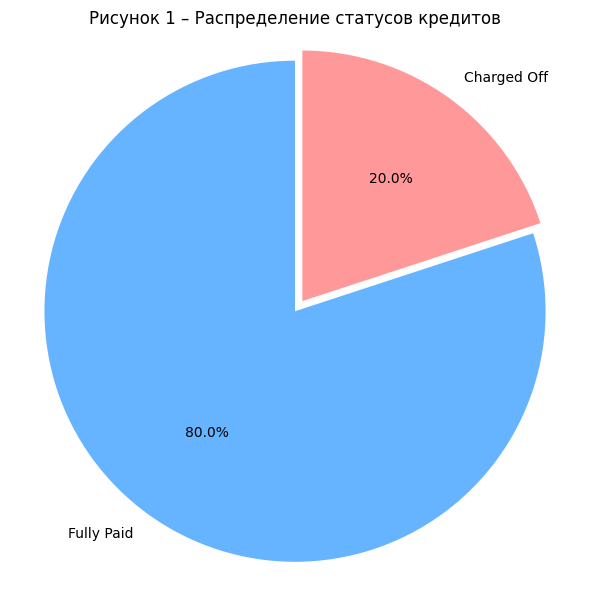

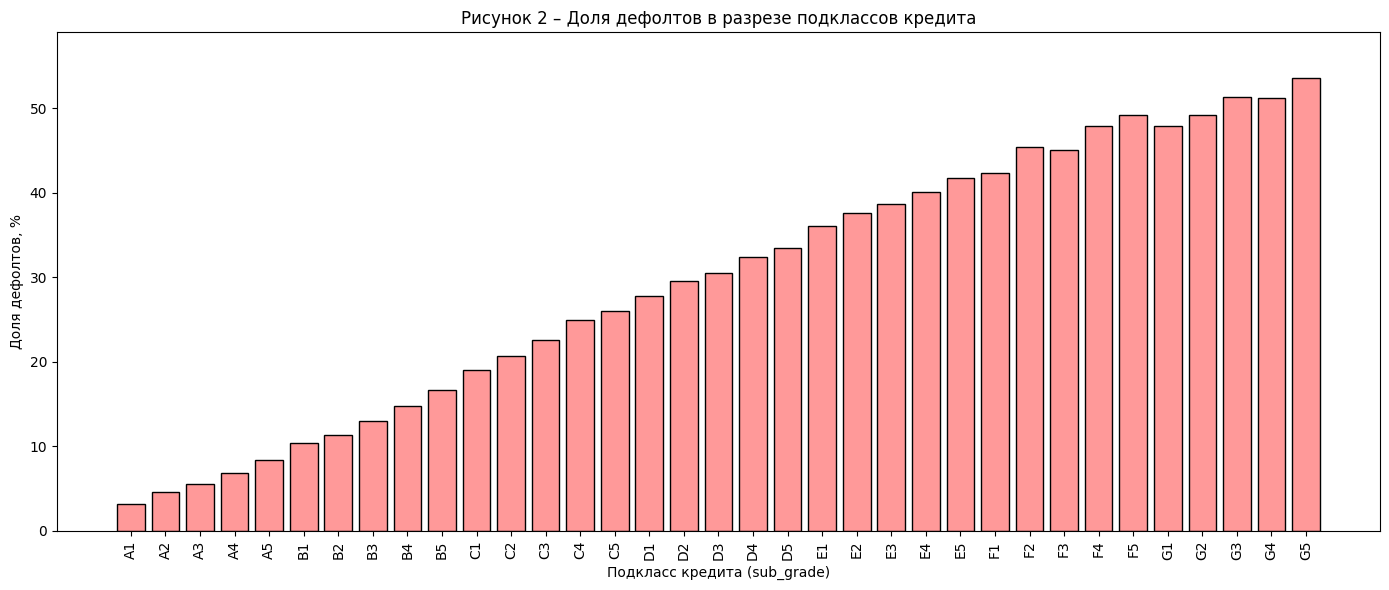

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Предполагается, что переменная df уже загружена (accepted_2007_to_2018Q4.csv.gz)
# и содержит все исходные столбцы датасета Lending Club

# 1. Оставляем только завершённые кредиты и создаём целевую метку
data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data['default'] = (data['loan_status'] == 'Charged Off').astype(int)

# 2. Для второго графика нужен исходный sub_grade, поэтому сохраняем его
#    и удаляем строки с пропусками в sub_grade и default
data_eda = data[['sub_grade', 'default']].dropna()

# ----------------------------
# Рисунок 1 – Круговая диаграмма распределения статусов
# ----------------------------
status_counts = data_eda['default'].value_counts()
labels = ['Fully Paid', 'Charged Off']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6,6))
plt.pie(status_counts.values, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=(0, 0.05))
plt.title('Рисунок 1 – Распределение статусов кредитов')
plt.axis('equal')
plt.tight_layout()
plt.show()

# ----------------------------
# Рисунок 2 – Доля дефолтов в разрезе подклассов sub_grade
# ----------------------------
default_rate = data_eda.groupby('sub_grade')['default'].mean() * 100
# Сортируем подклассы в естественном порядке (A1, A2, ..., G5)
grade_order = sorted(default_rate.index.tolist())
default_rate = default_rate.reindex(grade_order)

plt.figure(figsize=(14,6))
plt.bar(grade_order, default_rate.values, color='#ff9999', edgecolor='black')
plt.xlabel('Подкласс кредита (sub_grade)')
plt.ylabel('Доля дефолтов, %')
plt.title('Рисунок 2 – Доля дефолтов в разрезе подклассов кредита')
plt.xticks(rotation=90)
plt.ylim(0, max(default_rate.values) * 1.1)
plt.tight_layout()
plt.show()